<a href="https://colab.research.google.com/github/vsinha027/QuantumInspireCodes/blob/main/qc2_QI_Integration_260810.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QC2–Quantum Inspire H$_2$ hardware-VQE workflow

**Authored by:**
Dr. Vivek Sinha
v.sinha@tudelft.nl

Date: August 10, 2026.


## Scope

This notebook demonstrates the technical integration of **QC2**, **Qiskit**, and the **Quantum Inspire (QI)** superconducting Tuna backends for molecular variational quantum eigensolver (VQE) calculations. H$_2$ in an STO-3G basis with a CAS(2,2) active space is used as a compact reference problem because the complete chemistry-to-hardware workflow can be inspected explicitly while retaining the same interfaces used for larger molecular systems.

The computational path is

```text
molecular geometry
    ↓
QC2 + PySCF
    ↓
QCSchema / active-space reduction
    ↓
second-quantized electronic Hamiltonian
    ↓
Jordan–Wigner mapping
    ↓
Qiskit SparsePauliOp
    ↓
parameterized quantum circuit
    ↓
QC2/Qiskit VQE
    ↓
BackendEstimatorV2
    ↓
qiskit-quantuminspire
    ↓
Quantum Inspire Tuna backend
```

QC2 provides the chemistry/problem-preparation layer and, in `qc2` hardware-VQE mode, also configures the Qiskit VQE algorithm. Qiskit's `BackendEstimatorV2` adapts the Quantum Inspire `BackendV2` object to the estimator interface expected by VQE. The QI provider then performs circuit submission and result retrieval from the selected Tuna processor.

Two execution modes are available:

- **`fixed_parameter`**: variational parameters are optimized locally with exact statevector expectation values, followed by QPU measurement of the selected state.
- **`hardware_vqe`**: the classical optimizer runs locally while molecular expectation values are evaluated on the QPU during optimization.

For `hardware_vqe`, two drivers are available. The `custom` driver evaluates the production readout-corrected/full-symmetry-verified objective inside the optimizer loop. The `qc2` driver uses QC2's Qiskit VQE class with generic `BackendEstimatorV2` expectation values during optimization and performs a separate production-quality confirmation measurement at the returned parameter vector.

---

## Molecular Hamiltonian

For fixed nuclei, the electronic Hamiltonian in second quantization is

$$
\hat{H}_{\mathrm{el}}
=
\sum_{pq} h_{pq}\,a_p^\dagger a_q
+
\frac{1}{2}
\sum_{pqrs}
g_{pqrs}\,
a_p^\dagger a_q^\dagger a_s a_r ,
$$

where $h_{pq}$ and $g_{pqrs}$ are one- and two-electron molecular-orbital integrals and $a_p^\dagger$, $a_p$ are fermionic creation and annihilation operators.

In this notebook, QC2 uses its ASE/PySCF interface to perform RHF/STO-3G calculations and stores the electronic-structure data using QCSchema. A CAS(2,2) problem is then constructed with one $\alpha$ and one $\beta$ active electron in two spatial orbitals. The four resulting spin orbitals map to four qubits through the Jordan–Wigner transformation.

The total VQE energy is evaluated as

$$
E(\boldsymbol{\theta})
=
E_{\mathrm{core}}
+
\left\langle
\psi(\boldsymbol{\theta})
\middle|
\hat{H}_{q}
\middle|
\psi(\boldsymbol{\theta})
\right\rangle ,
$$

where $E_{\mathrm{core}}$ is the geometry-dependent scalar contribution returned by QC2 and the qubit Hamiltonian has the Pauli expansion

$$
\hat{H}_{q}(R)
=
\sum_j c_j(R) P_j .
$$

For this four-qubit H$_2$ Jordan–Wigner model, the Hamiltonian contains 15 Pauli strings:

$$
\begin{aligned}
\hat{H}_{q}(R) ={}&
c_0\,IIII
+c_1\,IIIZ
+c_2\,IIZI
+c_3\,IZII
+c_4\,ZIII \\
&+c_5\,IIZZ
+c_6\,IZIZ
+c_7\,ZIIZ
+c_8\,IZZI
+c_9\,ZIZI
+c_{10}\,ZZII \\
&+c_{11}\,XXXX
+c_{12}\,XXYY
+c_{13}\,YYXX
+c_{14}\,YYYY .
\end{aligned}
$$

The coefficients $c_j(R)$ are generated by QC2 independently at each H–H separation $R$. Qiskit Pauli labels are written in the order $q_3q_2q_1q_0$.

The non-diagonal four-body terms require the five measurement bases used by the production measurement layer:

```text
ZZZZ, YYYY, XXYY, YYXX, XXXX
```

---

## H$_2$-specific minimal ansatz

The default ansatz is a one-parameter, two-determinant circuit designed for the H$_2$ CAS(2,2) subspace. Starting from $|0000\rangle$, the circuit applies

$$
R_y^{(0)}(2\theta),
\quad
\mathrm{CX}_{0,1},
\quad
\mathrm{CX}_{0,2},
\quad
\mathrm{CX}_{0,3},
\quad
X_0,
\quad
X_2 .
$$

The resulting state is

$$
|\psi(\theta)\rangle
=
\cos(\theta)\,|0101\rangle
+
\sin(\theta)\,|1010\rangle ,
$$

using the Qiskit computational-basis ordering $|q_3q_2q_1q_0\rangle$. This compact form spans the two determinants required for the minimal-basis H$_2$ singlet and provides an exact representation of the CAS(2,2) ground state within this model.

The logical circuit contains one variational parameter, three two-qubit entangling gates, one $R_y$ rotation and two $X$ gates. Its dependency depth is 5. For architecture-independent ansatz comparison, the notebook also decomposes every candidate ansatz into the common gate set `{rz, sx, x, cx}`; the minimal ansatz then has canonical depth 9 with three two-qubit gates. Before hardware execution, all ansätze are transpiled again against the selected Tuna subgraph and the actual device-specific depth, two-qubit-gate count and final mapping are reported. A direct star layout permits the minimal circuit to retain three two-qubit interactions without SWAP routing.

The notebook also provides `PUCCD`, spin-preserving `UCCSD`, `RealAmplitudes`, and `EfficientSU2` alternatives so that chemical expressibility can be compared with hardware circuit cost before QPU execution.

---

## Correlated readout correction and full symmetry verification

For four measured qubits, the readout-correction layer prepares all $2^4=16$ computational basis states and constructs a correlated assignment matrix $A$. If $\mathbf{p}_{\mathrm{meas}}$ is the measured probability vector, the corrected distribution is obtained from the calibrated inverse problem

$$
\mathbf{p}_{\mathrm{corr}}
\approx
A^{-1}\mathbf{p}_{\mathrm{meas}},
$$

using the routines in `QuantumInspireUtilities`.

The H$_2$ CAS(2,2) Jordan–Wigner Hamiltonian commutes with the two parity operators

$$
S_\alpha = IIZZ,
\qquad
S_\beta = ZZII ,
$$

with target eigenvalues $-1$ and $-1$. The simultaneous symmetry projector is

$$
\Pi
=
\frac{1}{4}
(I-S_\alpha)(I-S_\beta).
$$

For any Hamiltonian Pauli term $P$, the fully symmetry-verified expectation value is evaluated as

$$
\langle P\rangle_{\mathrm{SV}}
=
\frac{
\langle P\rangle
-\langle S_\alpha P\rangle
-\langle S_\beta P\rangle
+\langle S_\alpha S_\beta P\rangle
}{
1
-\langle S_\alpha\rangle
-\langle S_\beta\rangle
+\langle S_\alpha S_\beta\rangle
}.
$$

The five H$_2$ measurement bases are closed under multiplication by these symmetry operators, so full expectation-value symmetry verification does not require additional molecular measurement settings. The projector survival probability is retained as a diagnostic for symmetry leakage.

An optional reference-state error-mitigation (REM) calculation uses the independently preparable RHF reference state:

$$
E_{\mathrm{REM}}
=
E_{\mathrm{target}}^{\mathrm{HW}}
-
\left(
E_{\mathrm{RHF}}^{\mathrm{HW}}
-
E_{\mathrm{RHF}}^{\mathrm{exact}}
\right).
$$

The exact CAS/FCI solution is reserved for benchmarking and is not used as an error-mitigation reference.

---

## Tuna backend and physical layout

The Quantum Inspire Tuna processors are superconducting transmon devices with flux-tunable couplers. Tuna-9 contains nine transmons in a diamond-like topology with 12 tunable nearest-neighbour couplers and Q4 at the centre. Quantum Inspire documents 20 ns native single-qubit operations, 60 ns CZ gates and 800 ns measurement operations for the Tuna family; arbitrary single-qubit rotations are quantized to multiples of $\pi/36$ by the platform compiler.

The notebook uses an explicit logical-to-physical layout because the minimal ansatz requires logical $q_0$ to interact directly with $q_1$, $q_2$ and $q_3$. A calibration-aware star centred on a well-performing physical qubit can therefore avoid SWAP insertion. The selected mapping should be re-evaluated against the current public backend calibration/dashboard before each hardware campaign.


## 0. Reproducible software environment

The Colab environment is deliberately **version-pinned** because this workflow crosses four independently evolving software layers: electronic structure, QC2, Qiskit, and the Quantum Inspire provider.

The validated environment installed below contains:

| Component | Version used here | Role |
|---|---:|---|
| QC2 | `v1.1.3` | chemistry data model, active-space Hamiltonian generation, QC2 VQE driver |
| PySCF | `2.14.0` | RHF/STO-3G electronic-structure calculations through the QC2 ASE calculator |
| ASE | `3.29.0` | molecular geometry and calculator interface |
| Qiskit | `2.3.1` | circuits, transpilation and V2 primitives |
| Qiskit Nature | `0.8.0` | fermion-to-qubit mapping and chemistry circuit libraries |
| Qiskit Algorithms | `0.4.0` | VQE and classical optimizers |
| qiskit-quantuminspire | `0.18.1` | Qiskit `BackendV2` access to Quantum Inspire |
| QuantumInspireUtilities | pinned Git commit | correlated readout calibration/correction utilities |
| Quantum Inspire CLI | `3.5.3`, isolated environment | authentication only |

### Why the installation is structured this way

**1. The scientific environment is pinned.**  
A notebook that allows `pip` to resolve the newest compatible packages on every launch can change transpilation, primitive interfaces, optimizer behavior or readout-processing functions without any change to the notebook source. Pinning the main versions makes the integration layer reproducible and keeps the molecular and hardware workflows testable as a unit.

**2. QC2 `v1.1.3` is used with the Qiskit V2 primitive interface.**  
QC2 `v1.1.3` still imports the legacy `qiskit.primitives.Estimator` symbol at module-import time, while the hardware path in this notebook uses Qiskit's V2 estimator interface. A narrow runtime compatibility shim is therefore applied only when required for the QC2 import. The actual hardware estimator supplied to QC2 is the genuine `BackendEstimatorV2`, wrapping the Quantum Inspire `BackendV2` object.

**3. `BackendEstimatorV2` is used as the QC2-to-QI adapter.**  
Qiskit defines `BackendEstimatorV2` as a generic estimator implementation for arbitrary `BackendV2` providers. This allows QC2's VQE algorithm to call a standard estimator while `qiskit-quantuminspire` handles the provider-specific circuit submission. The generic backend estimator performs Pauli expectation estimation and does not provide provider-specific error mitigation. The independent production confirmation in this notebook therefore applies the correlated readout and full-symmetry-verification pipeline explicitly.

**4. The Quantum Inspire CLI is isolated from the scientific Python environment.**  
The current QI CLI is used only for authentication. Quantum Inspire recommends installing the CLI in an isolated environment (for example with `pipx`). In Colab, the notebook creates a dedicated `virtualenv` and installs `quantuminspire==3.5.3` there. This prevents CLI dependency resolution from modifying the pinned QC2/Qiskit environment. After login, QPU access is performed through `qiskit-quantuminspire`, rather than through the CLI.

**5. `QuantumInspireUtilities` is pinned to a commit.**  
The correlated readout workflow depends on utility functions for calibration-circuit insertion, raw-shot separation, assignment-matrix construction and corrected probability reconstruction. Pinning the repository commit fixes the exact implementation used for these operations.

**6. The provider wait policy is patched before QC2 hardware VQE.**  
The QI provider version used here defines a finite default wait in `QIJob.result()`. Qiskit's generic `BackendEstimatorV2` waits on backend jobs internally and does not expose a QI-specific queue timeout in the VQE interface. The notebook therefore changes the provider-level default to `timeout=None` for the lifetime of the runtime and verifies the effective signature before any QPU optimization. QI job IDs are also recorded immediately and provider jobs are serialized when supported, allowing completed jobs to be recovered without circuit resubmission.

### Colab restart

Run the installation cell once and then **restart the Colab runtime before continuing**. This ensures that Python imports the newly installed pinned packages and compiled extensions from a clean interpreter rather than retaining modules loaded from the original Colab image.


In [ ]:
from pathlib import Path
import subprocess
import sys

INSTALL_MARKER = Path("/content/.qc2_qi_h2_production_vqe_full_sv_v3")

if INSTALL_MARKER.exists():
    print("Validated qc2/QI environment is installed.")
else:
    packages = [
        "numpy>=2.2.6,<2.6",
        "scipy>=1.15,<1.19",
        "matplotlib>=3.8",
        "ase==3.29.0",
        "pyscf==2.14.0",
        "pylatexenc>=2.10",
        "qiskit==2.3.1",
        "qiskit-nature==0.8.0",
        "qiskit-algorithms==0.4.0",
        "qiskit-aer>=0.17,<0.18",
        "qiskit-quantuminspire==0.18.1",
        "git+https://github.com/qc2nl/qc2.git@v1.1.3",
        (
            "git+https://github.com/DiCarloLab-Delft/"
            "QuantumInspireUtilities.git@"
            "7508274b58464de11cc226d2dfec2fc2a8d53f32"
        ),
    ]
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            *packages,
        ]
    )
    INSTALL_MARKER.write_text("installed\n")
    print("Installation complete.")
    print("Restart the runtime before continuing.")


Installation complete.
Restart the runtime before continuing.


> **After the first installation, stop here and restart the Colab runtime.**
The screenshot below show how to do it.

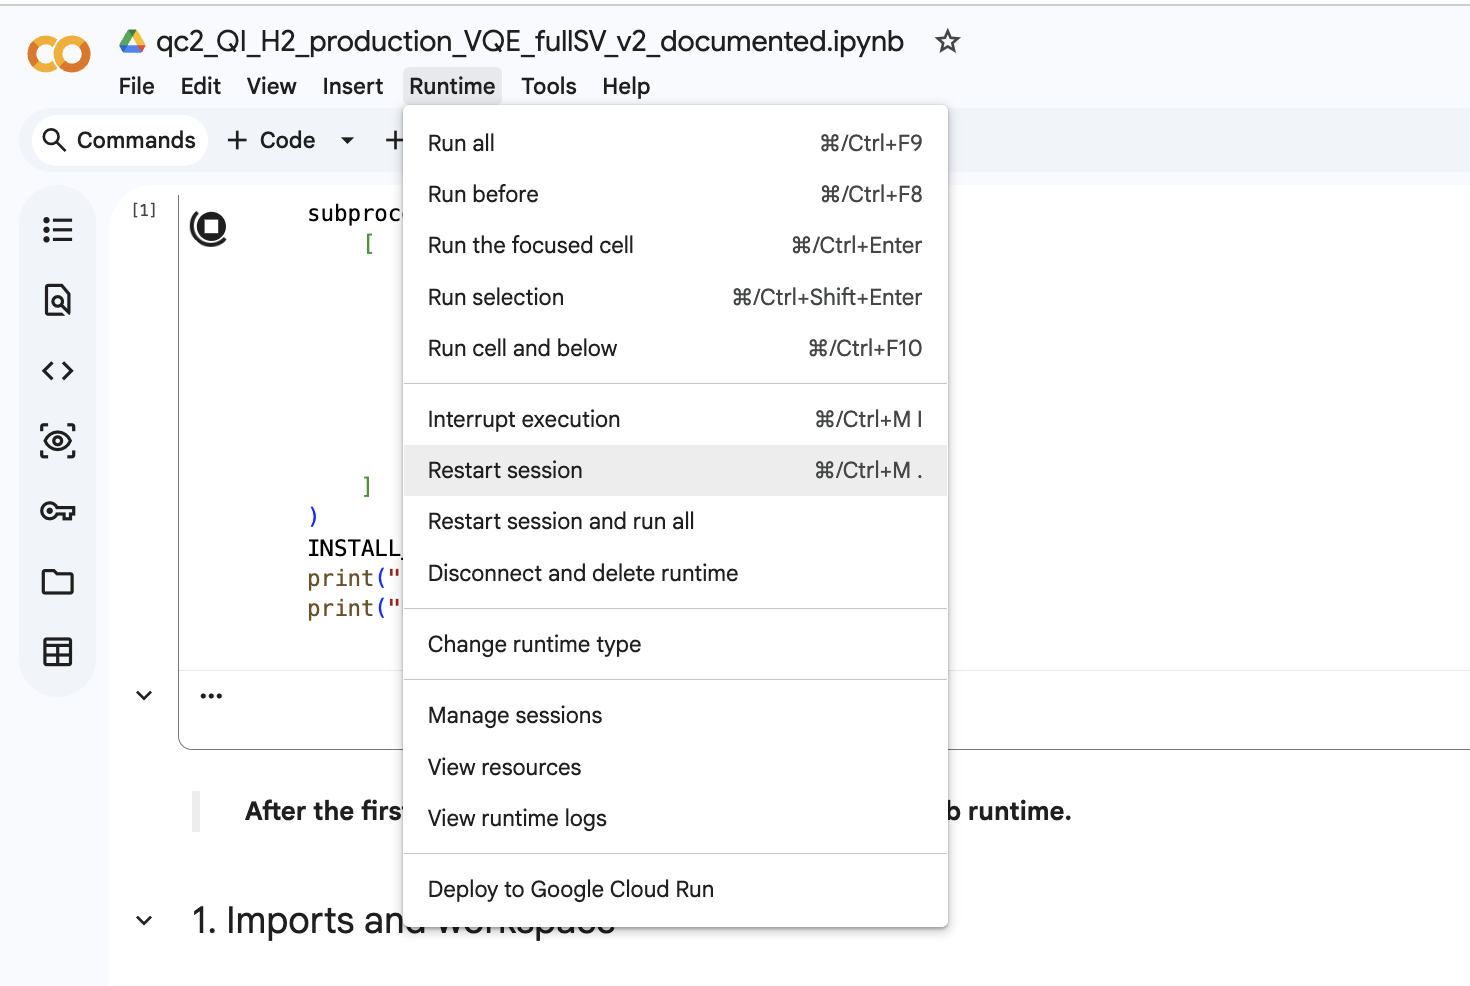

## 1. Imports and workspace

All chemistry, statevector optimization, classical VQE optimization, mitigation, and analysis execute locally. Only compiled quantum circuits are sent to Quantum Inspire.


In [ ]:
from contextlib import contextmanager
import copy
import csv
import inspect
import json
import math
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase import Atoms
from qiskit import ClassicalRegister, QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit.circuit.library import efficient_su2, real_amplitudes
from qiskit.quantum_info import Statevector
from qiskit.primitives import BackendEstimatorV2, StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE as QiskitAlgorithmsVQE
from qiskit_algorithms.optimizers import COBYLA as QiskitCOBYLA
from qiskit.transpiler import CouplingMap
from qiskit_nature.second_q.circuit.library import HartreeFock, PUCCD, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qc2.ase import PySCF
from qc2.data import qc2Data
from scipy.optimize import minimize

from qi_utilities.utility_functions.circuit_modifiers import (
    apply_readout_circuit,
)
from qi_utilities.utility_functions.raw_data_processing import (
    get_multi_counts,
    get_multi_probs,
)
from qi_utilities.utility_functions.readout_correction import (
    extract_ro_assignment_matrix,
    get_ro_corrected_multi_probs,
    plot_ro_assignment_matrix,
    split_raw_shots,
)

for package in [
    "numpy",
    "scipy",
    "ase",
    "pyscf",
    "qc2",
    "qiskit",
    "qiskit-nature",
    "qiskit-quantuminspire",
    "qi-utilities",
]:
    print(f"{package:28s} {version(package)}")

IN_COLAB = "google.colab" in sys.modules
BASE_WORKDIR = (
    Path("/content/qc2_qi_examples")
    if IN_COLAB
    else Path.cwd() / "qc2_qi_examples"
)
BASE_WORKDIR.mkdir(parents=True, exist_ok=True)
print("Base work directory:", BASE_WORKDIR)


numpy                        2.5.2
scipy                        1.18.0
ase                          3.29.0
pyscf                        2.14.0
qc2                          1.1.3
qiskit                       2.3.1
qiskit-nature                0.8.0
qiskit-quantuminspire        0.18.1
qi-utilities                 0.2.4
Base work directory: /content/qc2_qi_examples


# 2. Core helper library

The following helper cells only define functions/classes. They do not submit QI jobs.


## Helper 1 — QC2 Hamiltonian generation, ansatz registry, and exact-statevector optimization

At every geometry QC2 executes RHF/STO-3G through its PySCF ASE calculator, constructs the CAS(2,2) problem, and returns both the inactive/core contribution and the Qiskit-compatible Jordan–Wigner qubit Hamiltonian.

Every registered ansatz is optimized noiselessly before hardware execution. These parameters are used directly by `fixed_parameter` mode and retained as a reference/optional initialization for `hardware_vqe`.


In [ ]:
def build_qc2_hamiltonian(
    atoms,
    data_path,
    schema,
    active_electrons,
    active_orbitals,
    mapper,
    method="scf.RHF",
    basis="sto-3g",
):
    calculator = PySCF(
        method=str(method),
        basis=str(basis),
        verbose=0,
    )
    data = qc2Data(
        molecule=atoms,
        filename=str(data_path),
        schema=str(schema),
    )
    data.molecule.calc = calculator
    data.run()
    core_energy, qubit_hamiltonian = data.get_qubit_hamiltonian(
        tuple(active_electrons),
        int(active_orbitals),
        mapper,
        format="qiskit",
    )
    return {
        "atoms": atoms,
        "qc2data": data,
        "calculator": calculator,
        "reference_energy": float(calculator.mf.e_tot),
        "core_energy": float(core_energy),
        "qubit_hamiltonian": qubit_hamiltonian.simplify(atol=1e-10),
        "active_electrons": tuple(active_electrons),
        "active_orbitals": int(active_orbitals),
        "mapper": mapper,
        "data_path": str(data_path),
    }


def exact_qubit_ground_energy(qubit_hamiltonian):
    matrix = qubit_hamiltonian.to_matrix()
    return float(np.linalg.eigvalsh(matrix)[0].real)


ANSATZ_SPECS = {
    "minimal": {
        "label": "H2-specific minimal",
        "description": (
            "One-parameter H2-specific two-determinant circuit. "
            "Lowest logical gate overhead in this comparison."
        ),
        "default_bounds": (-0.5 * np.pi, 0.5 * np.pi),
    },
    "puccd": {
        "label": "PUCCD",
        "description": (
            "Paired unitary coupled-cluster doubles. Chemistry-inspired, "
            "particle/spin adapted for this singlet problem."
        ),
        "default_bounds": (-np.pi, np.pi),
    },
    "uccsd": {
        "label": "UCCSD",
        "description": (
            "Spin-preserving unitary coupled-cluster singles and doubles."
        ),
        "default_bounds": (-np.pi, np.pi),
    },
    "real_amplitudes": {
        "label": "RealAmplitudes (star, reps=1)",
        "description": (
            "Generic real-amplitude hardware-efficient ansatz with one "
            "star-entangling layer matching the logical H2/Tuna topology."
        ),
        "default_bounds": (-np.pi, np.pi),
    },
    "efficient_su2": {
        "label": "EfficientSU2 (star, reps=1)",
        "description": (
            "Generic hardware-efficient SU(2) ansatz with RY/RZ rotations "
            "and one star-entangling layer. More expressive than "
            "RealAmplitudes but does not conserve particle-number parity "
            "by construction."
        ),
        "default_bounds": (-np.pi, np.pi),
    },
}


def build_h2_ansatz(problem_record, ansatz_name):
    """Construct one of the registered four-qubit H2 ansätze.

    Returns
    -------
    reference_state : QuantumCircuit
        Hartree-Fock reference circuit.
    ansatz : QuantumCircuit
        Complete parameterized state-preparation circuit.
    parameter_bounds : list[tuple[float, float]]
        Bounds used by the local and hardware optimizers.
    """
    ansatz_name = str(ansatz_name).lower()
    if ansatz_name not in ANSATZ_SPECS:
        raise ValueError(
            f"Unknown ansatz {ansatz_name!r}; choose from "
            f"{list(ANSATZ_SPECS)}."
        )
    if (
        tuple(problem_record["active_electrons"]) != (1, 1)
        or int(problem_record["active_orbitals"]) != 2
    ):
        raise ValueError(
            "The current ansatz registry is configured for H2 CAS(2,2): "
            "active_electrons=(1, 1), active_orbitals=2."
        )

    number_spatial_orbitals = int(problem_record["active_orbitals"])
    number_particles = tuple(problem_record["active_electrons"])
    mapper = problem_record["mapper"]
    number_qubits = 2 * number_spatial_orbitals

    reference_state = HartreeFock(
        number_spatial_orbitals,
        number_particles,
        mapper,
    )

    if ansatz_name == "minimal":
        theta = Parameter("theta")
        ansatz = QuantumCircuit(number_qubits, name="minimal_H2")
        ansatz.ry(2.0 * theta, 0)
        ansatz.cx(0, 1)
        ansatz.cx(0, 2)
        ansatz.cx(0, 3)
        ansatz.x(0)
        ansatz.x(2)

    elif ansatz_name == "puccd":
        ansatz = PUCCD(
            num_spatial_orbitals=number_spatial_orbitals,
            num_particles=number_particles,
            qubit_mapper=mapper,
            reps=1,
            initial_state=reference_state,
        )

    elif ansatz_name == "uccsd":
        ansatz = UCCSD(
            num_spatial_orbitals=number_spatial_orbitals,
            num_particles=number_particles,
            qubit_mapper=mapper,
            reps=1,
            initial_state=reference_state,
            preserve_spin=True,
            generalized=False,
            include_imaginary=False,
        )

    elif ansatz_name == "real_amplitudes":
        # Use q0 as the logical star centre, matching the minimal circuit.
        body = real_amplitudes(
            number_qubits,
            entanglement=[(0, 1), (0, 2), (0, 3)],
            reps=1,
            parameter_prefix="ra",
        )
        ansatz = reference_state.compose(body)
        ansatz.name = "real_amplitudes_star"

    elif ansatz_name == "efficient_su2":
        # Hardware-efficient SU(2) circuit. The RY/RZ layers do not
        # conserve the H2 particle-number parity sector, so the full-SV
        # survival diagnostic is especially important on hardware.
        body = efficient_su2(
            number_qubits,
            su2_gates=["ry", "rz"],
            entanglement=[(0, 1), (0, 2), (0, 3)],
            reps=1,
            skip_final_rotation_layer=False,
            parameter_prefix="esu2",
        )
        ansatz = reference_state.compose(body)
        ansatz.name = "efficient_su2_star"

    if ansatz.num_parameters < 1:
        raise RuntimeError(
            f"Ansatz {ansatz_name!r} unexpectedly has no parameters."
        )

    low, high = ANSATZ_SPECS[ansatz_name]["default_bounds"]
    parameter_bounds = [
        (float(low), float(high))
        for _ in range(ansatz.num_parameters)
    ]
    return reference_state, ansatz, parameter_bounds


# Backward-compatible helper name used in earlier versions of this notebook.
def build_minimal_h2_ansatz(problem_record):
    reference_state, ansatz, _ = build_h2_ansatz(
        problem_record,
        "minimal",
    )
    return reference_state, ansatz


def bind_ansatz(ansatz, values):
    parameters = list(ansatz.parameters)
    values = np.atleast_1d(np.asarray(values, dtype=float))
    if len(values) != len(parameters):
        raise ValueError(
            f"Expected {len(parameters)} parameters; got {len(values)}."
        )
    return ansatz.assign_parameters(
        {
            parameter: float(value)
            for parameter, value in zip(parameters, values)
        }
    )


def statevector_energy(ansatz, values, qubit_hamiltonian):
    state = Statevector.from_instruction(bind_ansatz(ansatz, values))
    return float(np.real(state.expectation_value(qubit_hamiltonian)))


def canonical_ansatz_resources(ansatz):
    """Architecture-independent resource comparison.

    Each parameterized ansatz is decomposed to the same canonical
    {rz, sx, x, cx} gate set without imposing a coupling map. This is
    intended for ansatz-to-ansatz comparison only; the later QI section
    reports the actual depth and 2Q count after routing to the selected
    Tuna subgraph.
    """
    canonical = transpile(
        ansatz,
        basis_gates=["rz", "sx", "x", "cx"],
        optimization_level=0,
        seed_transpiler=11,
    )
    two_qubit_operations = [
        instruction
        for instruction in canonical.data
        if len(instruction.qubits) == 2
    ]
    return {
        "number_parameters": int(ansatz.num_parameters),
        "canonical_depth": int(canonical.depth()),
        "canonical_two_qubit_gates": len(two_qubit_operations),
        "canonical_circuit": canonical,
    }


def _unique_parameter_starts(starts, atol=1e-12):
    unique = []
    for start in starts:
        start = np.asarray(start, dtype=float).reshape(-1)
        if not any(np.allclose(start, old, atol=atol, rtol=0.0) for old in unique):
            unique.append(start)
    return unique


def optimize_h2_ansatz_statevector(
    problem_record,
    ansatz_name,
    initial_parameters=None,
    max_iterations=400,
    random_restarts=1,
    random_seed=17,
):
    """Optimize an ansatz against the exact statevector expectation value.

    This is deliberately independent of Quantum Inspire. It provides:
      1. the optimized parameters used by fixed_parameter mode;
      2. a noiseless ansatz-specific VQE reference for hardware_vqe mode.
    """
    reference_state, ansatz, parameter_bounds = build_h2_ansatz(
        problem_record,
        ansatz_name,
    )
    number_parameters = int(ansatz.num_parameters)

    starts = []
    if initial_parameters is not None:
        previous = np.asarray(initial_parameters, dtype=float).reshape(-1)
        if len(previous) == number_parameters:
            starts.append(previous)

    # Include a deterministic zero start for reproducibility.
    starts.append(np.zeros(number_parameters, dtype=float))

    rng = np.random.default_rng(int(random_seed))
    for _ in range(int(random_restarts)):
        starts.append(
            np.asarray(
                [
                    rng.uniform(low, high)
                    for low, high in parameter_bounds
                ],
                dtype=float,
            )
        )
    starts = _unique_parameter_starts(starts)

    all_runs = []
    best_result = None
    best_history = None

    for start_index, start in enumerate(starts):
        objective_history = []

        def objective(values):
            energy = statevector_energy(
                ansatz,
                values,
                problem_record["qubit_hamiltonian"],
            )
            objective_history.append(float(energy))
            return energy

        optimizer_result = minimize(
            objective,
            start,
            method="SLSQP",
            bounds=parameter_bounds,
            options={
                "maxiter": int(max_iterations),
                "ftol": 1e-12,
                "disp": False,
            },
        )
        all_runs.append(
            {
                "start_index": int(start_index),
                "initial_parameters": start.tolist(),
                "final_parameters": np.asarray(
                    optimizer_result.x,
                    dtype=float,
                ).tolist(),
                "active_energy": float(optimizer_result.fun),
                "success": bool(optimizer_result.success),
                "message": str(optimizer_result.message),
                "iterations": int(getattr(optimizer_result, "nit", -1)),
                "function_evaluations": int(
                    getattr(optimizer_result, "nfev", len(objective_history))
                ),
            }
        )
        if best_result is None or optimizer_result.fun < best_result.fun:
            best_result = optimizer_result
            best_history = objective_history

    exact_active = exact_qubit_ground_energy(
        problem_record["qubit_hamiltonian"]
    )
    exact_total = float(problem_record["core_energy"] + exact_active)
    vqe_total = float(problem_record["core_energy"] + best_result.fun)
    optimal_parameters = np.asarray(best_result.x, dtype=float)

    return {
        **problem_record,
        "ansatz_name": str(ansatz_name),
        "ansatz_label": ANSATZ_SPECS[str(ansatz_name)]["label"],
        "reference_state": reference_state,
        "ansatz": ansatz,
        "parameter_bounds": parameter_bounds,
        "optimal_parameters": optimal_parameters,
        "optimal_theta": (
            float(optimal_parameters[0])
            if len(optimal_parameters) == 1
            else None
        ),
        "vqe_active_energy": float(best_result.fun),
        "vqe_total_energy": vqe_total,
        "exact_active_energy": exact_active,
        "exact_total_energy": exact_total,
        "vqe_error_mha": 1000.0 * (vqe_total - exact_total),
        "optimizer_success": bool(best_result.success),
        "optimizer_message": str(best_result.message),
        "optimizer_iterations": int(getattr(best_result, "nit", -1)),
        "objective_history": best_history,
        "statevector_optimization_runs": all_runs,
    }


# Backward-compatible convenience function.
def optimize_minimal_h2(
    problem_record,
    initial_theta=0.0,
    max_iterations=100,
):
    return optimize_h2_ansatz_statevector(
        problem_record,
        "minimal",
        initial_parameters=[float(initial_theta)],
        max_iterations=max_iterations,
        random_restarts=0,
    )


## Helper 2 — strict layout, Pauli measurements, correlated readout correction, Z-sector filtering, and full SV

The production hardware path confines routing to the selected four-qubit Tuna subgraph, attaches a complete correlated four-qubit readout calibration to every Pauli measurement setting, reconstructs corrected probabilities from shot memory, and evaluates full two-symmetry expectation-value verification.

The Z-basis sector postselection is also analyzed as a diagnostic comparator to full SV.


In [ ]:
def install_qi_no_timeout_patch():
    """Make qiskit-quantuminspire QIJob.result() wait indefinitely by default.

    qiskit-quantuminspire 0.18.1 defines:
        QIJob.result(wait_for_results=True, timeout=60.0)

    Qiskit's BackendEstimatorV2 internally calls the backend job's
    ``result()`` method without forwarding a timeout. Therefore the
    provider's 60-second default must be changed at the QIJob layer.

    The original implementation is retained on the class so this patch is
    idempotent and affects only the current Python runtime.
    """
    from qiskit_quantuminspire.qi_jobs import QIJob

    if not hasattr(QIJob, "_qc2_qi_original_result"):
        QIJob._qc2_qi_original_result = QIJob.result

    original_result = QIJob._qc2_qi_original_result

    def result_without_default_timeout(
        self,
        wait_for_results=True,
        timeout=None,
    ):
        return original_result(
            self,
            wait_for_results=wait_for_results,
            timeout=timeout,
        )

    QIJob.result = result_without_default_timeout
    return QIJob


def verify_qi_no_timeout_patch():
    """Print and validate the effective QIJob.result signature."""
    from qiskit_quantuminspire.qi_jobs import QIJob

    signature = inspect.signature(QIJob.result)
    timeout_parameter = signature.parameters.get("timeout")
    print("Effective QIJob.result signature:", signature)

    if (
        timeout_parameter is None
        or timeout_parameter.default is not None
    ):
        raise RuntimeError(
            "QIJob.result still has a finite/default timeout. "
            "Do not run QC2 hardware VQE until this is fixed."
        )

    print(
        "PASS: QIJob.result() defaults to timeout=None "
        "(wait indefinitely)."
    )
    return signature


def qi_job_identifier(job):
    """Return the most useful QI/Qiskit job identifier available."""
    candidates = ("batch_job_id", "job_id", "id")
    for name in candidates:
        value = getattr(job, name, None)
        if value is None:
            continue
        if callable(value):
            try:
                value = value()
            except Exception:
                continue
        if value is not None and str(value).strip():
            return str(value)
    return None


def _safe_filename_token(value):
    value = str(value)
    return "".join(
        character if character.isalnum() or character in "-_"
        else "_"
        for character in value
    )


def serialize_qi_job_immediately(job, job_id=None):
    """Serialize a QIJob immediately after submission when supported.

    QIJob.serialize() preserves the submitted circuits, backend metadata,
    and batch-job metadata, allowing QIJob.deserialize() to reconstruct
    the provider job later.
    """
    serialization_dir = globals().get(
        "QI_JOB_SERIALIZATION_DIR"
    )
    if serialization_dir is None:
        return None

    serialize_method = getattr(job, "serialize", None)
    if not callable(serialize_method):
        return None

    serialization_dir = Path(serialization_dir)
    serialization_dir.mkdir(parents=True, exist_ok=True)

    token = _safe_filename_token(
        job_id if job_id is not None else "unknown"
    )
    path = serialization_dir / f"qi_job_{token}.qpy"

    try:
        serialize_method(path)
        print(f"QI job serialized: {path}", flush=True)
        return str(path)
    except Exception as error:
        print(
            "WARNING: QI job serialization failed: "
            f"{type(error).__name__}: {error}",
            flush=True,
        )
        return None


def _append_qi_job_ledger(record):
    """Persist one submission record immediately after backend.run()."""
    ledger_path = globals().get("QI_JOB_LEDGER_PATH")
    if ledger_path is None:
        return

    ledger_path = Path(ledger_path)
    ledger_path.parent.mkdir(parents=True, exist_ok=True)
    payload = json.dumps(record, default=str)

    with ledger_path.open("a", encoding="utf-8") as handle:
        handle.write(payload + "\n")
        handle.flush()
        try:
            os.fsync(handle.fileno())
        except OSError:
            pass


def record_qi_job_submission(job, backend, context=None):
    """Print, serialize, and persist a QI job before any blocking wait."""
    job_id = qi_job_identifier(job)

    if job_id is None:
        print(
            "QI job submitted; identifier unavailable from returned "
            f"{type(job).__name__} object.",
            flush=True,
        )
    else:
        print(f"QI job submitted: {job_id}", flush=True)

    serialized_path = serialize_qi_job_immediately(
        job,
        job_id=job_id,
    )

    record = {
        "submitted_utc": datetime.now(timezone.utc).isoformat(),
        "backend": str(
            getattr(backend, "name", type(backend).__name__)
        ),
        "job_id": job_id,
        "job_object_type": type(job).__name__,
        "serialized_job_path": serialized_path,
        "context": dict(context or {}),
    }
    _append_qi_job_ledger(record)

    ledger_path = globals().get("QI_JOB_LEDGER_PATH")
    if ledger_path is not None:
        print(f"QI job ledger: {ledger_path}", flush=True)

    return job_id, record


def submit_qi_job(
    backend,
    circuits,
    *,
    shots,
    memory=True,
    context=None,
):
    """Submit one QI backend job and preserve recovery information."""
    job = backend.run(
        circuits,
        shots=int(shots),
        memory=bool(memory),
    )
    job_id, record = record_qi_job_submission(
        job,
        backend,
        context=context,
    )
    return job, job_id, record


def wait_for_qi_job(job, label=None):
    """Wait indefinitely for a submitted QI job."""
    prefix = f"{label}: " if label else ""
    print(
        f"{prefix}waiting for Quantum Inspire completion "
        "(timeout=None).",
        flush=True,
    )
    # Explicitly pass None. Do not rely only on the runtime patch here.
    result = job.result(
        wait_for_results=True,
        timeout=None,
    )
    print(
        f"{prefix}Quantum Inspire job completed.",
        flush=True,
    )
    return result


def read_qi_job_ledger():
    """Return all submission records stored in the current job ledger."""
    ledger_path = globals().get("QI_JOB_LEDGER_PATH")
    if ledger_path is None or not Path(ledger_path).exists():
        return []

    records = []
    with Path(ledger_path).open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def recover_serialized_qi_job(
    provider,
    *,
    job_id=None,
    serialized_path=None,
    wait=True,
):
    """Recover a previously serialized QIJob and optionally wait for it.

    This recovers the provider-level Qiskit ``Result`` without resubmitting
    the circuit. It does not automatically reconstruct a SciPy/Qiskit
    optimizer state after an algorithm-level exception.
    """
    from qiskit_quantuminspire.qi_jobs import QIJob

    if serialized_path is None:
        if job_id is None:
            raise ValueError(
                "Provide either job_id or serialized_path."
            )
        serialization_dir = Path(
            globals()["QI_JOB_SERIALIZATION_DIR"]
        )
        serialized_path = (
            serialization_dir
            / f"qi_job_{_safe_filename_token(job_id)}.qpy"
        )

    serialized_path = Path(serialized_path)
    if not serialized_path.exists():
        raise FileNotFoundError(
            f"Serialized QI job not found: {serialized_path}"
        )

    recovered_job = QIJob.deserialize(
        provider,
        serialized_path,
    )
    print(
        "Recovered QI job:",
        qi_job_identifier(recovered_job),
    )
    print("Status:", recovered_job.status())

    if not wait:
        return recovered_job, None

    result = recovered_job.result(
        wait_for_results=True,
        timeout=None,
    )
    print("Recovered QI result successfully.")
    return recovered_job, result


@contextmanager
def capture_backend_job_submissions(
    backend,
    *,
    context_prefix="backend_estimator",
):
    """Capture QI jobs hidden inside BackendEstimatorV2.

    Each returned QIJob is printed, serialized, and added to the ledger
    before BackendEstimatorV2 calls ``job.result()``. Because the provider
    patch changes QIJob.result's default to timeout=None, the estimator's
    internal no-argument ``job.result()`` call now waits indefinitely.
    """
    records = []
    original_run = backend.run
    patched = False

    def logged_run(*args, **kwargs):
        job = original_run(*args, **kwargs)
        _, record = record_qi_job_submission(
            job,
            backend,
            context={
                "workflow": str(context_prefix),
                "estimator_backend_call": len(records) + 1,
            },
        )
        records.append(record)
        return job

    try:
        backend.run = logged_run
        patched = True
    except Exception as error:
        raise RuntimeError(
            "Could not instrument backend.run for QC2/BackendEstimator "
            "job recovery. Refusing to start a production QC2 VQE run."
        ) from error

    try:
        yield records
    finally:
        if patched:
            backend.run = original_run



def group_qubitwise_commuting(operator):
    groups = []
    for label, coefficient in operator.to_list():
        label = str(label)
        placed = False
        for group in groups:
            compatible = all(
                old == "I" or new == "I" or old == new
                for old, new in zip(group["basis"], label)
            )
            if compatible:
                group["basis"] = "".join(
                    new if old == "I" else old
                    for old, new in zip(group["basis"], label)
                )
                group["terms"].append(
                    (label, complex(coefficient))
                )
                placed = True
                break
        if not placed:
            groups.append(
                {
                    "basis": label,
                    "terms": [(label, complex(coefficient))],
                }
            )
    return groups


def chunks(items, maximum_size):
    maximum_size = int(maximum_size)
    return [
        items[start : start + maximum_size]
        for start in range(0, len(items), maximum_size)
    ]


def pauli_expectation_from_probabilities(label, probabilities):
    expectation = 0.0
    for raw_bits, probability in probabilities.items():
        bits = str(raw_bits).replace(" ", "").zfill(len(label))
        sign = 1
        for pauli, bit in zip(label, bits):
            if pauli != "I" and bit == "1":
                sign *= -1
        expectation += sign * float(probability)
    return float(expectation)


def energy_from_group_probabilities(groups, probability_blocks):
    energy = 0.0 + 0.0j
    for group, probabilities in zip(groups, probability_blocks):
        for label, coefficient in group["terms"]:
            energy += coefficient * pauli_expectation_from_probabilities(
                label,
                probabilities,
            )
    return float(np.real(energy))



# ---------------------------------------------------------------------
# Full H2 symmetry verification for the four-qubit JW representation
#
# Qiskit Pauli-label ordering is q3 q2 q1 q0.
# Qiskit Nature block-spin ordering has q0,q1 as alpha spin orbitals
# and q2,q3 as beta spin orbitals. For H2 CAS(2,2), N_alpha=N_beta=1:
#
#   S_alpha = IIZZ, eigenvalue -1
#   S_beta  = ZZII, eigenvalue -1
#
# The simultaneous projector is
#   Pi = (I - S_alpha)(I - S_beta) / 4.
# ---------------------------------------------------------------------

H2_SV_SYMMETRIES = (
    ("alpha_parity", "IIZZ", -1.0),
    ("beta_parity", "ZZII", -1.0),
)

_PAULI_PRODUCT = {
    ("I", "I"): ("I", 1.0),
    ("I", "X"): ("X", 1.0),
    ("I", "Y"): ("Y", 1.0),
    ("I", "Z"): ("Z", 1.0),
    ("X", "I"): ("X", 1.0),
    ("Y", "I"): ("Y", 1.0),
    ("Z", "I"): ("Z", 1.0),
    ("X", "X"): ("I", 1.0),
    ("Y", "Y"): ("I", 1.0),
    ("Z", "Z"): ("I", 1.0),
    ("X", "Y"): ("Z", 1.0j),
    ("Y", "X"): ("Z", -1.0j),
    ("Y", "Z"): ("X", 1.0j),
    ("Z", "Y"): ("X", -1.0j),
    ("Z", "X"): ("Y", 1.0j),
    ("X", "Z"): ("Y", -1.0j),
}


def multiply_pauli_labels(left, right):
    """Return (label, phase) for the operator product left * right."""
    if len(left) != len(right):
        raise ValueError("Pauli labels must have equal length.")
    output = []
    phase = 1.0 + 0.0j
    for a, b in zip(left, right):
        c, local_phase = _PAULI_PRODUCT[(a, b)]
        output.append(c)
        phase *= local_phase
    return "".join(output), complex(phase)


def pauli_labels_commute(left, right):
    """Return True when two Pauli strings commute."""
    if len(left) != len(right):
        raise ValueError("Pauli labels must have equal length.")
    number_anticommuting_positions = sum(
        1
        for a, b in zip(left, right)
        if a != "I" and b != "I" and a != b
    )
    return (number_anticommuting_positions % 2) == 0


def group_can_measure_pauli(group_basis, pauli_label):
    """Check whether a QWC measurement basis measures pauli_label."""
    return all(
        pauli == "I" or pauli == basis
        for pauli, basis in zip(pauli_label, group_basis)
    )


def pauli_expectation_from_group_blocks(
    pauli_label,
    groups,
    probability_blocks,
):
    """Extract a Pauli expectation from the existing QWC blocks."""
    if all(pauli == "I" for pauli in pauli_label):
        return 1.0
    for group, probabilities in zip(groups, probability_blocks):
        if group_can_measure_pauli(group["basis"], pauli_label):
            return pauli_expectation_from_probabilities(
                pauli_label,
                probabilities,
            )
    raise RuntimeError(
        "No existing measurement group can estimate "
        f"{pauli_label}. Existing bases are "
        f"{[group['basis'] for group in groups]}."
    )


def phased_pauli_expectation(
    pauli_label,
    phase,
    groups,
    probability_blocks,
    atol=1e-10,
):
    """Evaluate <phase * P>; the relevant symmetry products are real."""
    phase = complex(phase)
    if abs(phase.imag) > atol:
        raise RuntimeError(
            f"Unexpected imaginary phase {phase} for {pauli_label}. "
            "Check the symmetry and Pauli ordering."
        )
    return float(
        phase.real
        * pauli_expectation_from_group_blocks(
            pauli_label,
            groups,
            probability_blocks,
        )
    )


def h2_full_sv_diagnostics(groups, probability_blocks):
    """Evaluate symmetry expectations and physical-sector survival."""
    sa_label = "IIZZ"
    sb_label = "ZZII"
    sa_expectation = pauli_expectation_from_group_blocks(
        sa_label,
        groups,
        probability_blocks,
    )
    sb_expectation = pauli_expectation_from_group_blocks(
        sb_label,
        groups,
        probability_blocks,
    )
    sab_label, sab_phase = multiply_pauli_labels(sa_label, sb_label)
    sab_expectation = phased_pauli_expectation(
        sab_label,
        sab_phase,
        groups,
        probability_blocks,
    )
    denominator = (
        1.0
        - sa_expectation
        - sb_expectation
        + sab_expectation
    )
    survival_probability = denominator / 4.0
    if survival_probability <= 1e-10:
        raise RuntimeError(
            "Negligible probability in the desired H2 "
            "N_alpha=N_beta=1 symmetry sector."
        )
    return {
        "alpha_parity_expectation": float(sa_expectation),
        "beta_parity_expectation": float(sb_expectation),
        "total_parity_expectation": float(sab_expectation),
        "projector_denominator": float(denominator),
        "survival_probability": float(survival_probability),
    }


def h2_symmetry_verified_pauli_expectation(
    pauli_label,
    groups,
    probability_blocks,
    denominator=None,
):
    """
    Project <P> simultaneously onto IIZZ=-1 and ZZII=-1:

      <P>_SV =
        [<P> - <Sa P> - <Sb P> + <Sa Sb P>]
        / [1 - <Sa> - <Sb> + <Sa Sb>].
    """
    sa_label = "IIZZ"
    sb_label = "ZZII"
    if not pauli_labels_commute(pauli_label, sa_label):
        raise RuntimeError(
            f"Hamiltonian term {pauli_label} does not commute with "
            f"{sa_label}."
        )
    if not pauli_labels_commute(pauli_label, sb_label):
        raise RuntimeError(
            f"Hamiltonian term {pauli_label} does not commute with "
            f"{sb_label}."
        )

    p_expectation = pauli_expectation_from_group_blocks(
        pauli_label,
        groups,
        probability_blocks,
    )
    sa_p_label, sa_p_phase = multiply_pauli_labels(
        sa_label,
        pauli_label,
    )
    sa_p_expectation = phased_pauli_expectation(
        sa_p_label,
        sa_p_phase,
        groups,
        probability_blocks,
    )
    sb_p_label, sb_p_phase = multiply_pauli_labels(
        sb_label,
        pauli_label,
    )
    sb_p_expectation = phased_pauli_expectation(
        sb_p_label,
        sb_p_phase,
        groups,
        probability_blocks,
    )
    sab_label, sab_phase = multiply_pauli_labels(sa_label, sb_label)
    sab_p_label, sab_p_phase = multiply_pauli_labels(
        sab_label,
        pauli_label,
    )
    sab_p_expectation = phased_pauli_expectation(
        sab_p_label,
        sab_phase * sab_p_phase,
        groups,
        probability_blocks,
    )

    if denominator is None:
        denominator = h2_full_sv_diagnostics(
            groups,
            probability_blocks,
        )["projector_denominator"]
    if denominator <= 1e-10:
        raise RuntimeError(
            "Symmetry-projector denominator is too small: "
            f"{denominator:.6e}"
        )

    numerator = (
        p_expectation
        - sa_p_expectation
        - sb_p_expectation
        + sab_p_expectation
    )
    return float(numerator / denominator)


def h2_full_symmetry_verified_energy(groups, probability_blocks):
    """Return active-space energy and diagnostics after full H2 SV."""
    diagnostics = h2_full_sv_diagnostics(
        groups,
        probability_blocks,
    )
    denominator = diagnostics["projector_denominator"]
    energy = 0.0 + 0.0j
    sv_expectations = {}
    for group in groups:
        for label, coefficient in group["terms"]:
            expectation_sv = h2_symmetry_verified_pauli_expectation(
                label,
                groups,
                probability_blocks,
                denominator=denominator,
            )
            sv_expectations[label] = expectation_sv
            energy += complex(coefficient) * expectation_sv
    if abs(energy.imag) > 1e-9:
        raise RuntimeError(
            "Symmetry-verified energy acquired an unexpected "
            f"imaginary component: {energy.imag}"
        )
    diagnostics = dict(diagnostics)
    diagnostics["pauli_expectations"] = sv_expectations
    return float(energy.real), diagnostics


def validate_h2_sv_measurement_closure(
    qubit_hamiltonian,
    groups,
    verbose=False,
):
    """
    Check that P, Sa*P, Sb*P and Sa*Sb*P are all measurable from the
    existing QWC groups. This prevents silently applying SV to an
    incompatible Hamiltonian or mapping.
    """
    symmetry_labels = ("IIII", "IIZZ", "ZZII", "ZZZZ")
    missing = []
    for h_label, _ in qubit_hamiltonian.to_list():
        h_label = str(h_label)
        for symmetry_label in symmetry_labels:
            product_label, phase = multiply_pauli_labels(
                symmetry_label,
                h_label,
            )
            if abs(complex(phase).imag) > 1e-10:
                missing.append(
                    (h_label, symmetry_label, product_label, phase)
                )
                continue
            matching_bases = [
                group["basis"]
                for group in groups
                if group_can_measure_pauli(
                    group["basis"],
                    product_label,
                )
            ]
            if not matching_bases:
                missing.append(
                    (h_label, symmetry_label, product_label, phase)
                )
    if missing:
        raise RuntimeError(
            "Existing measurement groups are not closed under the "
            f"H2 symmetries. Missing products: {missing}"
        )
    if verbose:
        print("Full H2 symmetry-verification closure check: PASS")
        print("Measurement bases:", [g["basis"] for g in groups])
    return True


def valid_h2_sector(bitstring):
    '''
    Qiskit Nature uses block-spin ordering for four JW qubits:
    q0,q1 are alpha and q2,q3 are beta spin orbitals.
    H2 has one electron in each spin sector.
    '''
    bits_q0_first = str(bitstring).replace(" ", "")[::-1]
    if len(bits_q0_first) != 4:
        raise ValueError("The H2 sector check requires four bits.")
    alpha_number = sum(int(bit) for bit in bits_q0_first[0:2])
    beta_number = sum(int(bit) for bit in bits_q0_first[2:4])
    return alpha_number == 1 and beta_number == 1


def postselect_h2_z_sector(probabilities):
    kept = {
        bits: float(probability)
        for bits, probability in probabilities.items()
        if valid_h2_sector(bits)
    }
    survival = float(sum(kept.values()))
    if survival <= 1e-12:
        raise RuntimeError(
            "No probability remained in the physical H2 sector."
        )
    return (
        {
            bits: probability / survival
            for bits, probability in kept.items()
        },
        survival,
    )


def z_sector_probability_blocks(groups, probability_blocks):
    filtered_blocks = []
    survivals = []
    for group, probabilities in zip(groups, probability_blocks):
        is_z_basis = all(
            pauli in {"I", "Z"}
            for pauli in group["basis"]
        )
        if is_z_basis:
            filtered, survival = postselect_h2_z_sector(
                probabilities
            )
            filtered_blocks.append(filtered)
            survivals.append(float(survival))
        else:
            filtered_blocks.append(dict(probabilities))
    return filtered_blocks, survivals


def restricted_coupling_map(backend, physical_qubits):
    '''
    Restrict routing to the selected physical subgraph.
    This prevents SABRE from borrowing poorly calibrated neighbours.
    '''
    target = getattr(backend, "target", None)
    if target is None:
        return None
    backend_map = target.build_coupling_map()
    if backend_map is None:
        return None

    selected = set(int(q) for q in physical_qubits)
    restricted = CouplingMap()
    backend_width = int(getattr(backend, "num_qubits", max(selected) + 1))
    for qubit in range(backend_width):
        restricted.add_physical_qubit(qubit)
    for qubit_a, qubit_b in backend_map.get_edges():
        if qubit_a in selected and qubit_b in selected:
            restricted.add_edge(qubit_a, qubit_b)

    undirected_adjacency = {qubit: set() for qubit in selected}
    for qubit_a, qubit_b in restricted.get_edges():
        if qubit_a in selected and qubit_b in selected:
            undirected_adjacency[qubit_a].add(qubit_b)
            undirected_adjacency[qubit_b].add(qubit_a)
    reached = {next(iter(selected))}
    frontier = list(reached)
    while frontier:
        qubit = frontier.pop()
        for neighbour in undirected_adjacency[qubit] - reached:
            reached.add(neighbour)
            frontier.append(neighbour)
    if reached != selected:
        raise RuntimeError(
            f"Physical qubits {sorted(selected)} are not connected "
            f"on {backend.name}."
        )
    return restricted


def compile_state_preparation(
    logical_state,
    backend,
    physical_qubits,
    optimization_level=3,
    seed_transpiler=11,
):
    physical_qubits = [int(q) for q in physical_qubits]
    if logical_state.num_qubits != len(physical_qubits):
        raise ValueError(
            f"State has {logical_state.num_qubits} logical qubits, "
            f"but the layout has {len(physical_qubits)} entries."
        )
    backend_width = getattr(backend, "num_qubits", None)
    if (
        backend_width is not None
        and max(physical_qubits) >= int(backend_width)
    ):
        raise ValueError(
            f"Layout {physical_qubits} exceeds the width of "
            f"{backend.name}."
        )

    transpile_arguments = {
        "circuits": logical_state,
        "backend": backend,
        "initial_layout": physical_qubits,
        "optimization_level": int(optimization_level),
        "seed_transpiler": int(seed_transpiler),
    }
    coupling_map = restricted_coupling_map(
        backend,
        physical_qubits,
    )
    if coupling_map is not None:
        transpile_arguments["coupling_map"] = coupling_map
        transpile_arguments["routing_method"] = "sabre"

    compiled = transpile(**transpile_arguments)
    if compiled.layout is None:
        final_physical_qubits = list(physical_qubits)
    else:
        final_physical_qubits = list(
            compiled.layout.final_index_layout(
                filter_ancillas=True
            )[: logical_state.num_qubits]
        )

    if not set(final_physical_qubits).issubset(set(physical_qubits)):
        raise RuntimeError(
            "Routing left the selected physical subgraph: "
            f"final mapping {final_physical_qubits}, "
            f"selected {physical_qubits}."
        )

    two_qubit_operations = []
    for instruction in compiled.data:
        if len(instruction.qubits) == 2:
            pair = tuple(
                compiled.find_bit(qubit).index
                for qubit in instruction.qubits
            )
            two_qubit_operations.append(
                (instruction.operation.name, pair)
            )

    return {
        "circuit": compiled,
        "initial_physical_qubits": physical_qubits,
        "final_physical_qubits": final_physical_qubits,
        "depth": int(compiled.depth()),
        "two_qubit_gate_count": len(two_qubit_operations),
        "two_qubit_operations": two_qubit_operations,
    }


def add_physical_measurement(
    compiled_state,
    final_physical_qubits,
    basis,
    name,
):
    circuit = compiled_state.copy()
    circuit.name = str(name)
    number_logical_qubits = len(final_physical_qubits)
    if len(basis) != number_logical_qubits:
        raise ValueError("Measurement basis has the wrong width.")

    measurement_bits = ClassicalRegister(
        number_logical_qubits,
        "meas",
    )
    circuit.add_register(measurement_bits)
    circuit.barrier()
    for logical_qubit, pauli in enumerate(reversed(basis)):
        physical_qubit = int(
            final_physical_qubits[logical_qubit]
        )
        if pauli == "X":
            circuit.h(physical_qubit)
        elif pauli == "Y":
            circuit.sdg(physical_qubit)
            circuit.h(physical_qubit)
        circuit.measure(
            physical_qubit,
            measurement_bits[logical_qubit],
        )
    return circuit


def freeze_physical_circuit(circuit, backend, seed_transpiler=11):
    '''
    The state is already routed. Preserve every physical index while
    decomposing only the final one-qubit and readout-calibration blocks.
    '''
    return transpile(
        circuit,
        backend=backend,
        initial_layout=list(range(circuit.num_qubits)),
        layout_method="trivial",
        routing_method="none",
        optimization_level=1,
        seed_transpiler=int(seed_transpiler),
    )


def build_mitigated_state_measurements(
    logical_state,
    groups,
    backend,
    physical_qubits,
    state_label,
    point_index,
    optimization_level=3,
    seed_transpiler=11,
):
    state_record = compile_state_preparation(
        logical_state,
        backend,
        physical_qubits,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
    )
    circuits = []
    descriptors = []
    for group_index, group in enumerate(groups):
        circuit = add_physical_measurement(
            state_record["circuit"],
            state_record["final_physical_qubits"],
            group["basis"],
            (
                f"h2_p{point_index:03d}_{state_label}_"
                f"g{group_index}_{group['basis']}"
            ),
        )
        circuit = apply_readout_circuit(
            circuit,
            state_record["final_physical_qubits"],
        )
        circuit = freeze_physical_circuit(
            circuit,
            backend,
            seed_transpiler=seed_transpiler,
        )
        circuits.append(circuit)
        descriptors.append(
            {
                "state": str(state_label),
                "group_index": int(group_index),
                "physical_qubits": list(
                    state_record["final_physical_qubits"]
                ),
            }
        )
    return circuits, descriptors, state_record


def process_mitigated_circuit_result(
    qi_result,
    circuit_index,
    physical_qubits,
):
    experiment_shots, calibration_shots = split_raw_shots(
        qi_result,
        physical_qubits,
        circuit_nr=int(circuit_index),
    )
    assignment_matrix = extract_ro_assignment_matrix(
        calibration_shots,
        physical_qubits,
    )
    if not np.allclose(
        np.sum(assignment_matrix, axis=0),
        1.0,
        atol=1e-8,
    ):
        raise RuntimeError(
            "Readout assignment-matrix columns do not sum to one."
        )

    raw_counts = get_multi_counts(
        experiment_shots,
        len(physical_qubits),
    )
    if len(raw_counts) != 1:
        raise RuntimeError(
            "Expected exactly one experiment measurement block."
        )
    raw_probabilities = get_multi_probs(raw_counts)[0]
    corrected_probabilities = get_ro_corrected_multi_probs(
        [raw_probabilities],
        assignment_matrix,
        physical_qubits,
    )[0]

    corrected_values = np.asarray(
        list(corrected_probabilities.values()),
        dtype=float,
    )
    if (
        not np.all(np.isfinite(corrected_values))
        or not np.isclose(np.sum(corrected_values), 1.0, atol=1e-8)
        or np.min(corrected_values) < -1e-10
        or np.max(corrected_values) > 1.0 + 1e-10
    ):
        raise RuntimeError(
            "Readout correction returned invalid probabilities."
        )
    return {
        "raw_probabilities": raw_probabilities,
        "corrected_probabilities": corrected_probabilities,
        "assignment_matrix": assignment_matrix,
        "assignment_fidelity": float(
            np.mean(np.diag(assignment_matrix))
        ),
        "assignment_condition_number": float(
            np.linalg.cond(assignment_matrix)
        ),
    }


def run_qi_mitigated_h2_point(
    vqe_record,
    backend,
    physical_qubits,
    shots=4096,
    max_circuits_per_batch=5,
    max_readout_events_per_batch=500_000,
    optimization_level=3,
    seed_transpiler=11,
    apply_z_sector_postselection=True,
    apply_rem=True,
):
    """Execute one fixed parameter vector on QI.

    When ``apply_rem`` is True, the RHF reference state is also measured
    and used for reference-state error mitigation (REM). Exact CAS/FCI is
    never used as a mitigation reference; it is retained only as a
    benchmark.
    """
    groups = group_qubitwise_commuting(
        vqe_record["qubit_hamiltonian"]
    )
    validate_h2_sv_measurement_closure(
        vqe_record["qubit_hamiltonian"],
        groups,
        verbose=False,
    )

    bound_variational = bind_ansatz(
        vqe_record["ansatz"],
        vqe_record["optimal_parameters"],
    )
    state_circuits = {
        "variational": bound_variational,
    }
    if apply_rem:
        state_circuits["rhf"] = vqe_record["reference_state"]

    circuits = []
    descriptors = []
    state_compilation = {}
    for state_label, logical_state in state_circuits.items():
        (
            state_measurements,
            state_descriptors,
            state_record,
        ) = build_mitigated_state_measurements(
            logical_state,
            groups,
            backend,
            physical_qubits,
            state_label,
            int(vqe_record["point_index"]),
            optimization_level=optimization_level,
            seed_transpiler=seed_transpiler,
        )
        circuits.extend(state_measurements)
        descriptors.extend(state_descriptors)
        state_compilation[state_label] = state_record

    effective_shots = int(shots)
    backend_max_shots = getattr(backend, "max_shots", None)
    if backend_max_shots is not None and int(backend_max_shots) > 0:
        effective_shots = min(
            effective_shots,
            int(backend_max_shots),
        )

    number_qubits = len(physical_qubits)
    number_calibration_states = 2 ** number_qubits
    batches = chunks(
        list(zip(circuits, descriptors)),
        max_circuits_per_batch,
    )
    probability_blocks = {
        state: {
            "raw": [None] * len(groups),
            "readout": [None] * len(groups),
        }
        for state in state_circuits
    }
    assignment_fidelities = []
    assignment_condition_numbers = []
    assignment_matrices = []
    assignment_matrices_by_state = {
        state: [] for state in state_circuits
    }
    batch_job_ids = []

    print("Selected ansatz:", vqe_record.get("ansatz_name", "unknown"))
    print("Measurement settings:", [g["basis"] for g in groups])
    print("State preparations:", list(state_circuits))
    print("QI batches for this point:", len(batches))
    for state_label, state_record in state_compilation.items():
        print(
            f"  {state_label}: depth={state_record['depth']}, "
            f"2Q gates={state_record['two_qubit_gate_count']}, "
            "final mapping="
            f"{state_record['final_physical_qubits']}"
        )

    for batch_index, batch in enumerate(batches):
        batch_circuits = [item[0] for item in batch]
        batch_descriptors = [item[1] for item in batch]
        readout_events = (
            len(batch_circuits)
            * (1 + number_calibration_states)
            * effective_shots
        )
        if readout_events > int(max_readout_events_per_batch):
            raise RuntimeError(
                f"Batch {batch_index + 1} requires "
                f"{readout_events} readout events per qubit; "
                f"the configured limit is "
                f"{max_readout_events_per_batch}. Reduce QI_SHOTS."
            )

        print(
            f"Submitting batch {batch_index + 1}/{len(batches)}: "
            f"{len(batch_circuits)} circuits, "
            f"{readout_events} readout events/qubit"
        )
        job, batch_id, _submission_record = submit_qi_job(
            backend,
            batch_circuits,
            shots=effective_shots,
            memory=True,
            context={
                "workflow": "production_full_sv_measurement",
                "distance_angstrom": float(
                    vqe_record["distance_angstrom"]
                ),
                "batch_index": int(batch_index + 1),
                "number_batches": int(len(batches)),
                "states": sorted(
                    set(
                        item["state"]
                        for item in batch_descriptors
                    )
                ),
            },
        )
        if batch_id is not None:
            batch_job_ids.append(str(batch_id))

        result = wait_for_qi_job(
            job,
            label=(
                f"QI batch {batch_index + 1}/{len(batches)}"
            ),
        )
        if getattr(result, "system_messages", None):
            print("QI system messages:", result.system_messages)

        for circuit_index, descriptor in enumerate(
            batch_descriptors
        ):
            processed = process_mitigated_circuit_result(
                result,
                circuit_index,
                descriptor["physical_qubits"],
            )
            state_label = descriptor["state"]
            group_index = descriptor["group_index"]
            probability_blocks[state_label]["raw"][
                group_index
            ] = processed["raw_probabilities"]
            probability_blocks[state_label]["readout"][
                group_index
            ] = processed["corrected_probabilities"]
            assignment_fidelities.append(
                processed["assignment_fidelity"]
            )
            assignment_condition_numbers.append(
                processed["assignment_condition_number"]
            )
            assignment_matrices.append(
                processed["assignment_matrix"]
            )
            assignment_matrices_by_state[state_label].append(
                processed["assignment_matrix"]
            )

    energies = {}
    z_sector_survival = {}
    full_sv_diagnostics = {}
    for state_label in state_circuits:
        raw_active = energy_from_group_probabilities(
            groups,
            probability_blocks[state_label]["raw"],
        )
        readout_active = energy_from_group_probabilities(
            groups,
            probability_blocks[state_label]["readout"],
        )

        sector_blocks, survivals = z_sector_probability_blocks(
            groups,
            probability_blocks[state_label]["readout"],
        )
        sector_active = energy_from_group_probabilities(
            groups,
            sector_blocks,
        )
        if not apply_z_sector_postselection:
            sector_active = readout_active

        full_sv_active, state_sv_diagnostics = (
            h2_full_symmetry_verified_energy(
                groups,
                probability_blocks[state_label]["readout"],
            )
        )
        full_sv_diagnostics[state_label] = state_sv_diagnostics

        energies[state_label] = {
            "raw": float(vqe_record["core_energy"] + raw_active),
            "readout": float(
                vqe_record["core_energy"] + readout_active
            ),
            "readout_sector": float(
                vqe_record["core_energy"] + sector_active
            ),
            "readout_full_sv": float(
                vqe_record["core_energy"] + full_sv_active
            ),
        }
        z_sector_survival[state_label] = (
            float(np.mean(survivals))
            if survivals
            else float("nan")
        )

    if apply_rem:
        # Reference-state error mitigation:
        # E_REM = E_target_HW - (E_reference_HW - E_reference_exact).
        #
        # The reference must be a separately preparable state with a
        # classically known energy. Here that state is RHF. Using the exact
        # FCI target energy would be circular/oracular and is therefore not
        # offered as an REM option.
        rhf_exact = float(vqe_record["reference_energy"])
        rem_energy = float(
            energies["variational"]["readout"]
            - (energies["rhf"]["readout"] - rhf_exact)
        )
        sector_rem_energy = float(
            energies["variational"]["readout_sector"]
            - (
                energies["rhf"]["readout_sector"]
                - rhf_exact
            )
        )
        full_sv_rem_energy = float(
            energies["variational"]["readout_full_sv"]
            - (
                energies["rhf"]["readout_full_sv"]
                - rhf_exact
            )
        )
    else:
        rem_energy = float("nan")
        sector_rem_energy = float("nan")
        full_sv_rem_energy = float("nan")

    return {
        "ansatz_name": vqe_record.get("ansatz_name", "unknown"),
        "backend": backend.name,
        "shots_per_circuit": effective_shots,
        "physical_qubits": list(physical_qubits),
        "measurement_bases": [g["basis"] for g in groups],
        "number_measurement_circuits": len(circuits),
        "number_batches": len(batches),
        "batch_job_ids": batch_job_ids,
        "energies": energies,
        "rem_energy": rem_energy,
        "sector_rem_energy": sector_rem_energy,
        "full_sv_rem_energy": full_sv_rem_energy,
        "z_sector_survival": z_sector_survival,
        "full_sv_survival": {
            state: float(
                diagnostics["survival_probability"]
            )
            for state, diagnostics in full_sv_diagnostics.items()
        },
        "full_sv_diagnostics": full_sv_diagnostics,
        "mean_assignment_fidelity": float(
            np.mean(assignment_fidelities)
        ),
        "worst_assignment_condition_number": float(
            np.max(assignment_condition_numbers)
        ),
        "mean_assignment_matrix": np.mean(
            np.asarray(assignment_matrices),
            axis=0,
        ),
        "mean_assignment_matrix_by_state": {
            state: np.mean(np.asarray(matrices), axis=0)
            for state, matrices in assignment_matrices_by_state.items()
        },
        "state_compilation": state_compilation,
        "error_vs_exact_mha": {
            "raw": 1000.0
            * (
                energies["variational"]["raw"]
                - vqe_record["exact_total_energy"]
            ),
            "readout": 1000.0
            * (
                energies["variational"]["readout"]
                - vqe_record["exact_total_energy"]
            ),
            "readout_sector": 1000.0
            * (
                energies["variational"]["readout_sector"]
                - vqe_record["exact_total_energy"]
            ),
            "full_sv": 1000.0
            * (
                energies["variational"]["readout_full_sv"]
                - vqe_record["exact_total_energy"]
            ),
            "rem": (
                1000.0
                * (
                    rem_energy - vqe_record["exact_total_energy"]
                )
                if np.isfinite(rem_energy)
                else float("nan")
            ),
            "sector_rem": 1000.0
            * (
                sector_rem_energy - vqe_record["exact_total_energy"]
            ),
            "full_sv_rem": (
                1000.0
                * (
                    full_sv_rem_energy
                    - vqe_record["exact_total_energy"]
                )
                if np.isfinite(full_sv_rem_energy)
                else float("nan")
            ),
        },
    }


def resolve_point_selection(selection, number_points):
    text = str(selection).strip().lower()
    if text == "all":
        return list(range(int(number_points)))
    points = [
        int(token.strip())
        for token in text.split(",")
        if token.strip()
    ]
    invalid = [
        point
        for point in points
        if point < 0 or point >= int(number_points)
    ]
    if invalid:
        raise IndexError(
            f"Invalid points {invalid}; valid range is "
            f"0..{int(number_points) - 1}."
        )
    return list(dict.fromkeys(points))


## Helper 3 — custom hardware-in-the-loop VQE

The custom driver runs SciPy COBYLA locally. For each parameter vector it sends the selected ansatz to QI and evaluates the requested hardware objective.

The default objective is `readout_full_sv`, so the molecular symmetry projection participates in the optimizer loop itself. A fresh independent confirmation measurement is always performed at the returned parameter vector.


In [ ]:
def _effective_qi_shots(backend, requested_shots):
    effective_shots = int(requested_shots)
    backend_max_shots = getattr(backend, "max_shots", None)
    if backend_max_shots is not None and int(backend_max_shots) > 0:
        effective_shots = min(effective_shots, int(backend_max_shots))
    return effective_shots


def _compilation_summary(state_record):
    return {
        "initial_physical_qubits": list(
            state_record["initial_physical_qubits"]
        ),
        "final_physical_qubits": list(
            state_record["final_physical_qubits"]
        ),
        "depth": int(state_record["depth"]),
        "two_qubit_gate_count": int(
            state_record["two_qubit_gate_count"]
        ),
        "two_qubit_operations": [
            [name, list(pair)]
            for name, pair in state_record["two_qubit_operations"]
        ],
    }


def run_qi_h2_state_energy(
    vqe_record,
    parameter_values,
    backend,
    physical_qubits,
    shots=4096,
    max_circuits_per_batch=5,
    max_readout_events_per_batch=500_000,
    optimization_level=3,
    seed_transpiler=11,
    evaluation_index=0,
    apply_z_sector_postselection=True,
    verbose=True,
):
    """Measure one H2 variational state on Quantum Inspire.

    This is the hardware objective evaluator used by the local optimizer.
    The function performs the same correlated readout correction and full
    symmetry verification used by the fixed-parameter PEC notebook.
    """
    groups = group_qubitwise_commuting(
        vqe_record["qubit_hamiltonian"]
    )
    validate_h2_sv_measurement_closure(
        vqe_record["qubit_hamiltonian"],
        groups,
        verbose=False,
    )

    parameter_values = np.atleast_1d(
        np.asarray(parameter_values, dtype=float)
    )
    bound_state = bind_ansatz(
        vqe_record["ansatz"],
        parameter_values,
    )

    circuits, descriptors, state_record = (
        build_mitigated_state_measurements(
            bound_state,
            groups,
            backend,
            physical_qubits,
            state_label=f"vqe{int(evaluation_index):03d}",
            point_index=int(vqe_record["point_index"]),
            optimization_level=optimization_level,
            seed_transpiler=seed_transpiler,
        )
    )

    effective_shots = _effective_qi_shots(
        backend,
        shots,
    )
    number_qubits = len(physical_qubits)
    number_calibration_states = 2 ** number_qubits
    batches = chunks(
        list(zip(circuits, descriptors)),
        max_circuits_per_batch,
    )

    probability_blocks = {
        "raw": [None] * len(groups),
        "readout": [None] * len(groups),
    }
    assignment_fidelities = []
    assignment_condition_numbers = []
    batch_job_ids = []

    if verbose:
        print(
            f"  theta={parameter_values.tolist()} | "
            f"depth={state_record['depth']} | "
            f"2Q={state_record['two_qubit_gate_count']} | "
            "mapping="
            f"{state_record['final_physical_qubits']}"
        )

    for batch_index, batch in enumerate(batches):
        batch_circuits = [item[0] for item in batch]
        batch_descriptors = [item[1] for item in batch]
        readout_events = (
            len(batch_circuits)
            * (1 + number_calibration_states)
            * effective_shots
        )
        if readout_events > int(max_readout_events_per_batch):
            raise RuntimeError(
                f"Objective batch {batch_index + 1} requires "
                f"{readout_events} readout events/qubit; configured "
                f"limit is {max_readout_events_per_batch}."
            )

        if verbose:
            print(
                f"  submitting objective batch "
                f"{batch_index + 1}/{len(batches)}: "
                f"{len(batch_circuits)} circuits; "
                f"{readout_events} readout events/qubit"
            )

        job, batch_id, _submission_record = submit_qi_job(
            backend,
            batch_circuits,
            shots=effective_shots,
            memory=True,
            context={
                "workflow": "custom_hardware_vqe_objective",
                "distance_angstrom": float(
                    vqe_record["distance_angstrom"]
                ),
                "batch_index": int(batch_index + 1),
                "number_batches": int(len(batches)),
            },
        )
        if batch_id is not None:
            batch_job_ids.append(str(batch_id))

        result = wait_for_qi_job(
            job,
            label=(
                f"objective batch "
                f"{batch_index + 1}/{len(batches)}"
                if verbose
                else None
            ),
        )
        if getattr(result, "system_messages", None) and verbose:
            print("  QI system messages:", result.system_messages)

        for circuit_index, descriptor in enumerate(
            batch_descriptors
        ):
            processed = process_mitigated_circuit_result(
                result,
                circuit_index,
                descriptor["physical_qubits"],
            )
            group_index = descriptor["group_index"]
            probability_blocks["raw"][group_index] = (
                processed["raw_probabilities"]
            )
            probability_blocks["readout"][group_index] = (
                processed["corrected_probabilities"]
            )
            assignment_fidelities.append(
                processed["assignment_fidelity"]
            )
            assignment_condition_numbers.append(
                processed["assignment_condition_number"]
            )

    raw_active = energy_from_group_probabilities(
        groups,
        probability_blocks["raw"],
    )
    readout_active = energy_from_group_probabilities(
        groups,
        probability_blocks["readout"],
    )

    sector_blocks, survivals = z_sector_probability_blocks(
        groups,
        probability_blocks["readout"],
    )
    sector_active = energy_from_group_probabilities(
        groups,
        sector_blocks,
    )
    if not apply_z_sector_postselection:
        sector_active = readout_active

    full_sv_active, full_sv_diagnostics = (
        h2_full_symmetry_verified_energy(
            groups,
            probability_blocks["readout"],
        )
    )

    core_energy = float(vqe_record["core_energy"])
    energies = {
        "raw": float(core_energy + raw_active),
        "readout": float(core_energy + readout_active),
        "readout_sector": float(core_energy + sector_active),
        "readout_full_sv": float(core_energy + full_sv_active),
    }
    z_survival = (
        float(np.mean(survivals))
        if survivals
        else float("nan")
    )
    full_sv_survival = float(
        full_sv_diagnostics["survival_probability"]
    )

    if np.isfinite(z_survival) and not np.isclose(
        z_survival,
        full_sv_survival,
        atol=1e-7,
        rtol=1e-7,
    ):
        raise RuntimeError(
            "Z-sector and full-SV projector survival disagree: "
            f"{z_survival:.8f} vs {full_sv_survival:.8f}."
        )

    return {
        "parameter_values": parameter_values.tolist(),
        "energies": energies,
        "z_sector_survival": z_survival,
        "full_sv_survival": full_sv_survival,
        "full_sv_diagnostics": full_sv_diagnostics,
        "mean_assignment_fidelity": float(
            np.mean(assignment_fidelities)
        ),
        "worst_assignment_condition_number": float(
            np.max(assignment_condition_numbers)
        ),
        "batch_job_ids": batch_job_ids,
        "shots_per_circuit": int(effective_shots),
        "measurement_bases": [g["basis"] for g in groups],
        "compilation": _compilation_summary(state_record),
    }


def hardware_vqe_h2_point(
    vqe_record,
    backend,
    physical_qubits,
    initial_parameters=None,
    objective_mode="readout_full_sv",
    max_evaluations=12,
    rhobeg=0.15,
    tol=0.01,
    shots=4096,
    max_circuits_per_batch=5,
    max_readout_events_per_batch=500_000,
    optimization_level=3,
    seed_transpiler=11,
    apply_z_sector_postselection=True,
):
    """Run local COBYLA with every objective evaluation on QI hardware.

    The optimizer is fully classical and runs in the notebook process.
    Only parameterized state-preparation/measurement circuits are sent
    to Quantum Inspire.
    """
    allowed_modes = {
        "raw",
        "readout",
        "readout_sector",
        "readout_full_sv",
    }
    if objective_mode not in allowed_modes:
        raise ValueError(
            f"objective_mode must be one of {sorted(allowed_modes)}; "
            f"got {objective_mode!r}."
        )

    number_parameters = int(vqe_record["ansatz"].num_parameters)
    if initial_parameters is None:
        initial_parameters = np.zeros(number_parameters, dtype=float)
    initial_parameters = np.asarray(
        initial_parameters,
        dtype=float,
    ).reshape(-1)
    if len(initial_parameters) != number_parameters:
        raise ValueError(
            f"Expected {number_parameters} initial parameters; "
            f"got {len(initial_parameters)}."
        )

    parameter_bounds = vqe_record.get(
        "parameter_bounds",
        [(-np.pi, np.pi)] * number_parameters,
    )
    if len(parameter_bounds) != number_parameters:
        raise ValueError(
            "parameter_bounds length does not match ansatz parameter count."
        )

    history = []
    evaluation_counter = 0

    def objective(values):
        nonlocal evaluation_counter
        evaluation_counter += 1
        values = np.asarray(values, dtype=float).reshape(-1)

        print("\n" + "-" * 72)
        print(
            f"Hardware-VQE objective evaluation "
            f"{evaluation_counter}/{int(max_evaluations)}"
        )
        print("Ansatz:", vqe_record.get("ansatz_name", "unknown"))
        print(
            "Parameters:",
            np.array2string(values, precision=7, separator=", "),
        )

        measurement = run_qi_h2_state_energy(
            vqe_record,
            values,
            backend,
            physical_qubits,
            shots=shots,
            max_circuits_per_batch=max_circuits_per_batch,
            max_readout_events_per_batch=(
                max_readout_events_per_batch
            ),
            optimization_level=optimization_level,
            seed_transpiler=seed_transpiler,
            evaluation_index=evaluation_counter,
            apply_z_sector_postselection=(
                apply_z_sector_postselection
            ),
            verbose=True,
        )
        objective_energy = float(
            measurement["energies"][objective_mode]
        )
        history_entry = {
            "evaluation": int(evaluation_counter),
            "parameters": values.tolist(),
            "objective_mode": str(objective_mode),
            "objective_energy_hartree": objective_energy,
            **measurement,
        }
        if len(values) == 1:
            history_entry["theta"] = float(values[0])
        history.append(history_entry)

        print(
            f"Hardware objective ({objective_mode}): "
            f"{objective_energy:.10f} Ha"
        )
        return objective_energy

    optimizer_result = minimize(
        objective,
        initial_parameters,
        method="COBYLA",
        bounds=parameter_bounds,
        tol=float(tol),
        options={
            "maxiter": int(max_evaluations),
            "rhobeg": float(rhobeg),
            "disp": True,
        },
    )

    optimal_parameters = np.asarray(
        optimizer_result.x,
        dtype=float,
    )
    return {
        "point_index": int(vqe_record["point_index"]),
        "distance_angstrom": float(
            vqe_record["distance_angstrom"]
        ),
        "ansatz_name": vqe_record.get("ansatz_name", "unknown"),
        "number_parameters": number_parameters,
        "objective_mode": str(objective_mode),
        "initial_parameters": initial_parameters.tolist(),
        "optimal_parameters": optimal_parameters.tolist(),
        "optimal_theta": (
            float(optimal_parameters[0])
            if len(optimal_parameters) == 1
            else None
        ),
        "optimizer_fun_hartree": float(optimizer_result.fun),
        "optimizer_success": bool(optimizer_result.success),
        "optimizer_message": str(optimizer_result.message),
        "optimizer_nfev": int(
            getattr(optimizer_result, "nfev", len(history))
        ),
        "objective_history": history,
    }


def run_hardware_vqe_with_confirmation(
    vqe_record,
    backend,
    physical_qubits,
    initial_parameters=None,
    objective_mode="readout_full_sv",
    max_evaluations=12,
    rhobeg=0.15,
    tol=0.01,
    shots=4096,
    max_circuits_per_batch=5,
    max_readout_events_per_batch=500_000,
    optimization_level=3,
    seed_transpiler=11,
    apply_z_sector_postselection=True,
    apply_rem=True,
):
    """Run hardware VQE and then make a fresh independent confirmation.

    Full symmetry verification is always applied to the confirmation.
    RHF REM is optional.
    """
    hardware_vqe = hardware_vqe_h2_point(
        vqe_record,
        backend,
        physical_qubits,
        initial_parameters=initial_parameters,
        objective_mode=objective_mode,
        max_evaluations=max_evaluations,
        rhobeg=rhobeg,
        tol=tol,
        shots=shots,
        max_circuits_per_batch=max_circuits_per_batch,
        max_readout_events_per_batch=(
            max_readout_events_per_batch
        ),
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
        apply_z_sector_postselection=(
            apply_z_sector_postselection
        ),
    )

    confirmation_record = copy.copy(vqe_record)
    confirmation_record["optimal_parameters"] = np.asarray(
        hardware_vqe["optimal_parameters"],
        dtype=float,
    )
    confirmation_record["optimal_theta"] = hardware_vqe["optimal_theta"]

    print("\n" + "=" * 72)
    print("Final independent confirmation at hardware-VQE parameters")
    confirmation = run_qi_mitigated_h2_point(
        confirmation_record,
        backend,
        physical_qubits=physical_qubits,
        shots=shots,
        max_circuits_per_batch=max_circuits_per_batch,
        max_readout_events_per_batch=(
            max_readout_events_per_batch
        ),
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
        apply_z_sector_postselection=(
            apply_z_sector_postselection
        ),
        apply_rem=apply_rem,
    )

    return {
        "hardware_vqe": hardware_vqe,
        "confirmation": confirmation,
    }


## Helper 4 — QC2-native hardware-VQE driver

This optional driver uses QC2's own Qiskit VQE class.

QC2 v1.1.3 still imports the legacy `qiskit.primitives.Estimator`, while Qiskit Algorithms 0.4.0 expects `BaseEstimatorV2`. The helper applies a narrow runtime import shim and explicitly supplies Qiskit's modern `BackendEstimatorV2`.

The helper also corrects a QC2 v1.1.3 result-reporting issue: QC2 currently stores the final callback sample as `optimal_energy`/`optimal_params`. The wrapper instead takes the actual optimizer optimum from Qiskit Algorithms' `VQEResult`.

The QI ansatz is transpiled through the same strict four-qubit subgraph policy used by the production path.

**Mitigation distinction:** generic `BackendEstimatorV2` does not implement this notebook's custom QI correlated-readout correction or full SV. Therefore the QC2 optimizer objective is generic shot-based estimator energy. After QC2 VQE finishes, the returned optimal parameter vector is independently remeasured with the production correlated-readout + full-SV protocol.


In [ ]:
def _import_qc2_vqe_with_qiskit2_compatibility():
    """Import QC2's Qiskit VQE under Qiskit 2.x.

    QC2 v1.1.3 imports ``qiskit.primitives.Estimator`` at module import
    time. Qiskit 2.x removed the V1 Estimator implementation. The shim
    only satisfies that legacy import; this notebook explicitly supplies
    genuine V2 estimators to QC2.
    """
    import qiskit.primitives as primitives

    shim_applied = False
    if not hasattr(primitives, "Estimator"):
        primitives.Estimator = StatevectorEstimator
        shim_applied = True

    from qc2.algorithms.qiskit import VQE as QC2BaseVQE
    from qc2.algorithms.algorithms_results import VQEResults
    from qc2.algorithms.utils import ActiveSpace

    return QC2BaseVQE, VQEResults, ActiveSpace, shim_applied


class StrictQITranspiler:
    """Qiskit-Algorithms transpiler adapter enforcing the chosen QI subgraph."""

    def __init__(
        self,
        backend,
        physical_qubits,
        optimization_level=3,
        seed_transpiler=11,
    ):
        self.backend = backend
        self.physical_qubits = [int(q) for q in physical_qubits]
        self.optimization_level = int(optimization_level)
        self.seed_transpiler = int(seed_transpiler)
        self.last_compilation = None

    def run(self, circuit, **kwargs):
        record = compile_state_preparation(
            circuit,
            self.backend,
            self.physical_qubits,
            optimization_level=self.optimization_level,
            seed_transpiler=self.seed_transpiler,
        )
        self.last_compilation = record
        return record["circuit"]


def _make_qc2_vqe_result_fixed_class():
    """Return a QC2 VQE subclass with corrected final-result reporting.

    QC2 v1.1.3 records the *last callback sample* as ``optimal_energy`` and
    ``optimal_params``. Qiskit Algorithms 0.4.0 exposes the optimizer's
    actual optimum in ``VQEResult.eigenvalue`` and ``optimal_point``.
    This subclass preserves QC2's VQE setup but uses those authoritative
    Qiskit result fields for the returned optimum.
    """
    QC2BaseVQE, VQEResults, _, shim_applied = (
        _import_qc2_vqe_with_qiskit2_compatibility()
    )

    class QC2VQEResultFixed(QC2BaseVQE):
        def run(self, **kwargs):
            self._init_qubit_hamiltonian()

            history = {
                "nfev": [],
                "energy": [],
                "metadata": [],
            }

            def callback(nfev, parameters, energy, metadata):
                total_energy = float(np.real(energy)) + float(self.e_core)
                history["nfev"].append(int(nfev))
                history["energy"].append(total_energy)
                history["metadata"].append(metadata)
                if self.verbose:
                    print(
                        f"QC2/Qiskit VQE eval {int(nfev):03d}: "
                        f"{total_energy:.12f} Ha"
                    )

            solver = QiskitAlgorithmsVQE(
                self.estimator,
                self.ansatz,
                self.optimizer,
                callback=callback,
                **kwargs,
            )
            solver.initial_point = np.asarray(self.params, dtype=float)

            qiskit_result = solver.compute_minimum_eigenvalue(
                self.qubit_op
            )

            result = VQEResults()
            result.optimizer_evals = int(
                qiskit_result.cost_function_evals
                if qiskit_result.cost_function_evals is not None
                else len(history["energy"])
            )
            result.optimal_energy = float(
                np.real(qiskit_result.eigenvalue)
                + float(self.e_core)
            )
            result.optimal_params = np.asarray(
                qiskit_result.optimal_point,
                dtype=float,
            )
            result.energy = list(history["energy"])
            # Qiskit Algorithms 0.4.0's callback parameter payload is not
            # reliable for reconstructing a multi-parameter trajectory.
            # The authoritative final vector is qiskit_result.optimal_point.
            result.parameters = []
            result.metadata = list(history["metadata"])

            print("=== QC2 / QISKIT VQE RESULTS (corrected wrapper) ===")
            print(
                "* Electronic ground state energy (Hartree):",
                qiskit_result.eigenvalue,
            )
            print("* Inactive core energy (Hartree):", self.e_core)
            print(
                ">>> Total optimal energy (Hartree):",
                result.optimal_energy,
            )
            print(
                ">>> Optimal parameter vector:",
                result.optimal_params,
            )
            return result

    return QC2VQEResultFixed, shim_applied


def run_qc2_hardware_vqe_with_confirmation(
    vqe_record,
    backend,
    physical_qubits,
    initial_parameters=None,
    max_evaluations=12,
    tol=0.01,
    shots=4096,
    max_circuits_per_batch=5,
    max_readout_events_per_batch=500_000,
    optimization_level=3,
    seed_transpiler=11,
    apply_z_sector_postselection=True,
    apply_rem=True,
):
    """Run QC2's VQE driver on QI, then perform the production full-SV confirmation.

    During optimization QC2 uses Qiskit's generic BackendEstimatorV2.
    Therefore the *QC2 optimizer objective itself* does not include the
    custom correlated readout correction or full SV. The final reported
    molecular result is always obtained from an independent confirmation
    measurement using the production readout + full-SV pipeline.
    """
    QC2VQE, shim_applied = _make_qc2_vqe_result_fixed_class()
    _, _, ActiveSpace, _ = _import_qc2_vqe_with_qiskit2_compatibility()

    number_parameters = int(vqe_record["ansatz"].num_parameters)
    if initial_parameters is None:
        initial_parameters = np.zeros(number_parameters, dtype=float)
    initial_parameters = np.asarray(
        initial_parameters,
        dtype=float,
    ).reshape(-1)
    if len(initial_parameters) != number_parameters:
        raise ValueError(
            f"Expected {number_parameters} initial parameters; "
            f"got {len(initial_parameters)}."
        )

    effective_shots = _effective_qi_shots(backend, shots)
    estimator = BackendEstimatorV2(
        backend=backend,
        options={
            "default_precision": 1.0 / np.sqrt(effective_shots),
            "abelian_grouping": True,
        },
    )
    strict_transpiler = StrictQITranspiler(
        backend,
        physical_qubits,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
    )

    qc2_vqe = QC2VQE(
        qc2data=vqe_record["qc2data"],
        ansatz=vqe_record["ansatz"],
        active_space=ActiveSpace(
            num_active_electrons=tuple(
                vqe_record["active_electrons"]
            ),
            num_active_spatial_orbitals=int(
                vqe_record["active_orbitals"]
            ),
        ),
        mapper="jw",
        estimator=estimator,
        optimizer=QiskitCOBYLA(
            maxiter=int(max_evaluations),
            tol=float(tol),
            rhobeg=float(HARDWARE_VQE_RHOBEG),
        ),
        reference_state=vqe_record["reference_state"],
        init_params=initial_parameters.tolist(),
        verbose=1,
    )

    print("QC2 Qiskit-2 compatibility shim applied:", shim_applied)
    print(
        "QC2 optimizer estimator: BackendEstimatorV2 "
        "(generic; no custom QI mitigation during optimization)"
    )

    with capture_backend_job_submissions(
        backend,
        context_prefix="qc2_vqe_backend_estimator",
    ) as qc2_submission_records:
        qc2_result = qc2_vqe.run(
            transpiler=strict_transpiler,
        )

    qc2_batch_job_ids = [
        record["job_id"]
        for record in qc2_submission_records
        if record.get("job_id") is not None
    ]

    optimal_parameters = np.asarray(
        qc2_result.optimal_params,
        dtype=float,
    ).reshape(-1)

    confirmation_record = copy.copy(vqe_record)
    confirmation_record["optimal_parameters"] = optimal_parameters
    confirmation_record["optimal_theta"] = (
        float(optimal_parameters[0])
        if len(optimal_parameters) == 1
        else None
    )

    print("\n" + "=" * 72)
    print("Independent production confirmation at QC2-VQE parameters")
    print("Applying correlated readout correction + full symmetry verification.")

    confirmation = run_qi_mitigated_h2_point(
        confirmation_record,
        backend,
        physical_qubits=physical_qubits,
        shots=shots,
        max_circuits_per_batch=max_circuits_per_batch,
        max_readout_events_per_batch=max_readout_events_per_batch,
        optimization_level=optimization_level,
        seed_transpiler=seed_transpiler,
        apply_z_sector_postselection=apply_z_sector_postselection,
        apply_rem=apply_rem,
    )

    history = [
        {
            "evaluation": i + 1,
            "objective_energy_hartree": float(energy),
        }
        for i, energy in enumerate(qc2_result.energy)
    ]

    compilation = (
        _compilation_summary(strict_transpiler.last_compilation)
        if strict_transpiler.last_compilation is not None
        else None
    )

    return {
        "hardware_vqe": {
            "driver": "qc2",
            "objective_mode": "BackendEstimatorV2",
            "objective_is_full_sv": False,
            "initial_parameters": initial_parameters.tolist(),
            "optimal_parameters": optimal_parameters.tolist(),
            "optimal_theta": (
                float(optimal_parameters[0])
                if len(optimal_parameters) == 1
                else None
            ),
            "optimizer_fun_hartree": float(qc2_result.optimal_energy),
            "optimizer_nfev": int(qc2_result.optimizer_evals),
            "objective_history": history,
            "batch_job_ids": qc2_batch_job_ids,
            "job_submission_records": qc2_submission_records,
            "qc2_compatibility_shim_applied": bool(shim_applied),
            "qc2_transpilation": compilation,
        },
        "confirmation": confirmation,
    }


# 3. Build the H₂ molecular reference curve with QC2


In [ ]:
WORKDIR = BASE_WORKDIR / "h2_production_vqe_full_sv"
WORKDIR.mkdir(parents=True, exist_ok=True)

ACTIVE_ELECTRONS = (1, 1)
ACTIVE_ORBITALS = 2
MAPPER = JordanWignerMapper()
EQUILIBRIUM_DISTANCE = 0.737166
R_DISTANCES = np.asarray(
    [
        scale * EQUILIBRIUM_DISTANCE
        for scale in np.arange(0.5, 5.0, 0.5)
    ],
    dtype=float,
)

h2_problem_records = []
print("Building QC2 molecular problems")
print("=" * 72)
for point_index, distance in enumerate(R_DISTANCES):
    h2_atoms = Atoms(
        "H2",
        positions=[
            [0.0, 0.0, 0.0],
            [0.0, 0.0, float(distance)],
        ],
    )
    problem = build_qc2_hamiltonian(
        atoms=h2_atoms,
        data_path=WORKDIR / f"h2_point_{point_index:03d}.hdf5",
        schema="qcschema",
        active_electrons=ACTIVE_ELECTRONS,
        active_orbitals=ACTIVE_ORBITALS,
        mapper=MAPPER,
        method="scf.RHF",
        basis="sto-3g",
    )
    problem["point_index"] = int(point_index)
    problem["distance_angstrom"] = float(distance)
    problem["exact_active_energy"] = exact_qubit_ground_energy(
        problem["qubit_hamiltonian"]
    )
    problem["exact_total_energy"] = float(
        problem["core_energy"] + problem["exact_active_energy"]
    )
    h2_problem_records.append(problem)
    print(
        f"point {point_index:2d}: r={distance:.6f} A | "
        f"RHF={problem['reference_energy']:.10f} Ha | "
        f"exact CAS/FCI={problem['exact_total_energy']:.10f} Ha"
    )


Building QC2 molecular problems
* Reference energy (Hartree): -0.8323959925858818
* Saving qchem data in /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_point_000.hdf5

point  0: r=0.368583 A | RHF=-0.8323959926 Ha | exact CAS/FCI=-0.8415563848 Ha
* Reference energy (Hartree): -1.11690055771897
* Saving qchem data in /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_point_001.hdf5

point  1: r=0.737166 A | RHF=-1.1169005577 Ha | exact CAS/FCI=-1.1373015638 Ha
* Reference energy (Hartree): -1.0347677703871998
* Saving qchem data in /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_point_002.hdf5

point  2: r=1.105749 A | RHF=-1.0347677704 Ha | exact CAS/FCI=-1.0778998227 Ha
* Reference energy (Hartree): -0.9186044326889025
* Saving qchem data in /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_point_003.hdf5

point  3: r=1.474332 A | RHF=-0.9186044327 Ha | exact CAS/FCI=-1.0023474333 Ha
* Reference energy (Hartree): -0.8185133354304794
* Saving qchem data in /content/

## 4. Compare all ansätze and optimize each one exactly

This cell performs the architecture-independent resource comparison and then optimizes **all five ansätze at all nine geometries using exact statevectors**.

The user selects an ansatz only after this comparison. `minimal` is the default.


In [ ]:
ANSATZ_CANDIDATES = [
    "minimal",
    "puccd",
    "uccsd",
    "real_amplitudes",
    "efficient_su2",
]

STATEVECTOR_MAX_ITERATIONS = 400
STATEVECTOR_RANDOM_RESTARTS = 1
STATEVECTOR_RANDOM_SEED = 17

# ------------------------------------------------------------------
# A. Architecture-independent circuit resources
# ------------------------------------------------------------------
ansatz_resource_summary = {}
probe_problem = h2_problem_records[1]

print("ANSATZ RESOURCE COMPARISON (canonical logical decomposition)")
print("=" * 96)
print(
    f"{'ansatz':20s} {'parameters':>10s} "
    f"{'depth':>10s} {'2Q gates':>10s}"
)
print("-" * 96)

for ansatz_name in ANSATZ_CANDIDATES:
    _, probe_ansatz, _ = build_h2_ansatz(
        probe_problem,
        ansatz_name,
    )
    resources = canonical_ansatz_resources(probe_ansatz)
    ansatz_resource_summary[ansatz_name] = resources
    print(
        f"{ansatz_name:20s} "
        f"{resources['number_parameters']:10d} "
        f"{resources['canonical_depth']:10d} "
        f"{resources['canonical_two_qubit_gates']:10d}"
    )

print(
    "\nNote: these are architecture-independent decomposition metrics. "
    "Actual Tuna depth/2Q counts are reported after the QI backend and "
    "physical layout are selected."
)

# ------------------------------------------------------------------
# B. Optimize every ansatz with exact statevectors at every geometry
# ------------------------------------------------------------------
h2_ansatz_records = {}

for ansatz_index, ansatz_name in enumerate(ANSATZ_CANDIDATES):
    print("\n" + "=" * 96)
    print(
        f"Exact-statevector optimization: "
        f"{ANSATZ_SPECS[ansatz_name]['label']}"
    )
    print("=" * 96)

    records = []
    previous_parameters = None

    for point_index, problem in enumerate(h2_problem_records):
        result = optimize_h2_ansatz_statevector(
            problem,
            ansatz_name,
            initial_parameters=previous_parameters,
            max_iterations=STATEVECTOR_MAX_ITERATIONS,
            random_restarts=STATEVECTOR_RANDOM_RESTARTS,
            random_seed=(
                STATEVECTOR_RANDOM_SEED
                + 1000 * ansatz_index
                + point_index
            ),
        )
        result["point_index"] = int(point_index)
        result["distance_angstrom"] = float(
            problem["distance_angstrom"]
        )
        records.append(result)
        previous_parameters = result["optimal_parameters"].copy()

        print(
            f"point {point_index:2d}: "
            f"r={result['distance_angstrom']:.6f} A | "
            f"params={result['ansatz'].num_parameters:2d} | "
            f"E={result['vqe_total_energy']:.10f} Ha | "
            f"error={result['vqe_error_mha']:+.6f} mHa"
        )

    h2_ansatz_records[ansatz_name] = records

# ------------------------------------------------------------------
# C. Accuracy summary across the complete PEC
# ------------------------------------------------------------------
print("\n" + "=" * 96)
print("NOISELESS ANSATZ ACCURACY ACROSS THE NINE-POINT PEC")
print("=" * 96)
print(
    f"{'ansatz':20s} {'params':>7s} {'depth':>8s} {'2Q':>6s} "
    f"{'MAE (mHa)':>12s} {'max |err|':>12s}"
)
print("-" * 96)

for ansatz_name in ANSATZ_CANDIDATES:
    records = h2_ansatz_records[ansatz_name]
    errors = np.asarray(
        [record["vqe_error_mha"] for record in records],
        dtype=float,
    )
    resources = ansatz_resource_summary[ansatz_name]
    print(
        f"{ansatz_name:20s} "
        f"{resources['number_parameters']:7d} "
        f"{resources['canonical_depth']:8d} "
        f"{resources['canonical_two_qubit_gates']:6d} "
        f"{np.mean(np.abs(errors)):12.6f} "
        f"{np.max(np.abs(errors)):12.6f}"
    )

# ------------------------------------------------------------------
# D. User selection
# ------------------------------------------------------------------
SELECTED_ANSATZ = "minimal"  # @param ["minimal", "puccd", "uccsd", "real_amplitudes", "efficient_su2"]

if SELECTED_ANSATZ not in h2_ansatz_records:
    raise ValueError(
        f"SELECTED_ANSATZ must be one of {ANSATZ_CANDIDATES}; "
        f"got {SELECTED_ANSATZ!r}."
    )

h2_vqe_records = h2_ansatz_records[SELECTED_ANSATZ]
rhf_energies = np.asarray(
    [record["reference_energy"] for record in h2_vqe_records]
)
exact_energies = np.asarray(
    [record["exact_total_energy"] for record in h2_vqe_records]
)
local_vqe_energies = np.asarray(
    [record["vqe_total_energy"] for record in h2_vqe_records]
)

print("\nSelected ansatz:", SELECTED_ANSATZ)
print("Description:", ANSATZ_SPECS[SELECTED_ANSATZ]["description"])
print(
    "Number of variational parameters:",
    h2_vqe_records[0]["ansatz"].num_parameters,
)
print(
    "The selected exact-statevector parameter vector at each geometry "
    "is stored in record['optimal_parameters']."
)


ANSATZ RESOURCE COMPARISON (canonical logical decomposition)
ansatz               parameters      depth   2Q gates
------------------------------------------------------------------------------------------------
minimal                       1          9          3
puccd                         1        114         48
uccsd                         3        136         56
real_amplitudes               8         14          3
efficient_su2                16         16          3

Note: these are architecture-independent decomposition metrics. Actual Tuna depth/2Q counts are reported after the QI backend and physical layout are selected.

Exact-statevector optimization: H2-specific minimal
point  0: r=0.368583 A | params= 1 | E=-0.8415563848 Ha | error=-0.000000 mHa
point  1: r=0.737166 A | params= 1 | E=-1.1373015638 Ha | error=-0.000000 mHa
point  2: r=1.105749 A | params= 1 | E=-1.0778998227 Ha | error=+0.000000 mHa
point  3: r=1.474332 A | params= 1 | E=-1.0023474333 Ha | error=-0.000

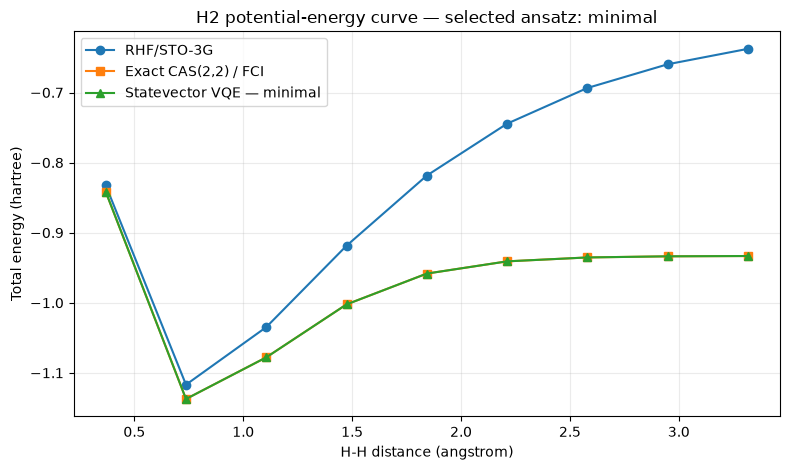

Selected ansatz statevector MAE: 0.000000 mHa
Selected ansatz maximum statevector error: 0.000000 mHa

Optimized equilibrium-point circuit:
     ┌──────────────┐               ┌───┐
q_0: ┤ Ry(-0.22441) ├──■────■────■──┤ X ├
     └──────────────┘┌─┴─┐  │    │  └───┘
q_1: ────────────────┤ X ├──┼────┼───────
                     └───┘┌─┴─┐  │  ┌───┐
q_2: ─────────────────────┤ X ├──┼──┤ X ├
                          └───┘┌─┴─┐└───┘
q_3: ──────────────────────────┤ X ├─────
                               └───┘     


In [ ]:
plt.figure(figsize=(8, 4.8))
plt.plot(
    R_DISTANCES,
    rhf_energies,
    "o-",
    label="RHF/STO-3G",
)
plt.plot(
    R_DISTANCES,
    exact_energies,
    "s-",
    label="Exact CAS(2,2) / FCI",
)
plt.plot(
    R_DISTANCES,
    local_vqe_energies,
    "^-",
    label=f"Statevector VQE — {SELECTED_ANSATZ}",
)
plt.xlabel("H-H distance (angstrom)")
plt.ylabel("Total energy (hartree)")
plt.title(
    "H2 potential-energy curve — "
    f"selected ansatz: {SELECTED_ANSATZ}"
)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

maximum_local_error = max(
    abs(record["vqe_error_mha"])
    for record in h2_vqe_records
)
mean_local_error = np.mean(
    [
        abs(record["vqe_error_mha"])
        for record in h2_vqe_records
    ]
)
print(
    "Selected ansatz statevector MAE:",
    f"{mean_local_error:.6f} mHa",
)
print(
    "Selected ansatz maximum statevector error:",
    f"{maximum_local_error:.6f} mHa",
)

if maximum_local_error > 1.0:
    print(
        "WARNING: the selected ansatz does not reproduce the exact "
        "CAS(2,2) curve to <1 mHa at every geometry. This is not a "
        "hardware error; it is ansatz/optimization error and should be "
        "kept separate when interpreting QI results."
    )

equilibrium_record = h2_vqe_records[1]
print("\nOptimized equilibrium-point circuit:")
print(
    bind_ansatz(
        equilibrium_record["ansatz"],
        equilibrium_record["optimal_parameters"],
    ).draw(output="text")
)


# 5. Connect to Quantum Inspire and choose the physical layout

The `qi` executable is installed in an isolated virtual environment and used only for authentication.

The production layout is a user-controlled logical→physical mapping. The H₂ minimal/RealAmplitudes/EfficientSU2 circuits use logical `q0` as a star centre, so the preferred Tuna layout gives that logical qubit three direct, well-performing physical links.

The included `[4, 2, 6, 1]` mapping was validated on Tuna-9 during the August 2026 campaign. **Re-check the live QI dashboard/calibration before a new campaign.** The notebook enforces the chosen four-qubit subgraph and raises if routing leaves it.


In [ ]:
QI_BACKEND_NAME = "Tuna-9"  # @param {type:"string"}
QI_SHOTS = 4096  # @param {type:"integer"}

QI_JOB_LEDGER_PATH = WORKDIR / "qi_submitted_jobs.jsonl"
QI_JOB_SERIALIZATION_DIR = WORKDIR / "qi_serialized_jobs"

# list position = logical qubit; list value = Tuna physical qubit.
# This was a good Tuna-9 star in the validated 2026-08 campaign.
# Re-check the live dashboard/calibration before a new campaign.
QI_INITIAL_LAYOUT = [4, 6, 7, 2]

QI_OPTIMIZATION_LEVEL = 3
QI_SEED_TRANSPILER = 11
MAX_CIRCUITS_PER_BATCH = 5
MAX_READOUT_EVENTS_PER_QUBIT_PER_BATCH = 500_000
APPLY_Z_SECTOR_POSTSELECTION = True

# REM is optional because it doubles the five-group state measurement
# workload at the final confirmation. The only production REM reference
# offered here is RHF.
APPLY_REM = True  # @param {type:"boolean"}
REM_REFERENCE = "rhf"  # intentionally fixed; exact FCI is benchmark only

print("Requested backend:", QI_BACKEND_NAME)
print("Shots per experiment/calibration state:", QI_SHOTS)
print("Apply RHF REM:", APPLY_REM)
print("REM reference:", REM_REFERENCE)
print("Manual logical-to-physical layout:")
for logical_qubit, physical_qubit in enumerate(QI_INITIAL_LAYOUT):
    print(
        f"  logical q{logical_qubit} "
        f"-> physical Q{physical_qubit}"
    )

if REM_REFERENCE.lower() != "rhf":
    raise ValueError(
        "Production REM in this notebook uses RHF only. "
        "Do not use exact FCI as an REM reference: that would use the "
        "target answer itself and make the correction circular."
    )

print("QI job ledger:", QI_JOB_LEDGER_PATH)

print("QI job serialization directory:", QI_JOB_SERIALIZATION_DIR)


Requested backend: Tuna-9
Shots per experiment/calibration state: 4096
Apply RHF REM: True
REM reference: rhf
Manual logical-to-physical layout:
  logical q0 -> physical Q4
  logical q1 -> physical Q6
  logical q2 -> physical Q7
  logical q3 -> physical Q2
QI job ledger: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_submitted_jobs.jsonl
QI job serialization directory: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_serialized_jobs


In [ ]:
from qiskit_quantuminspire.qi_provider import QIProvider


# Critical for BackendEstimatorV2 + qiskit-quantuminspire 0.18.1:
# BackendEstimatorV2 internally calls backend.run(...).result() without
# a timeout argument. QIJob.result otherwise defaults to 60 seconds.
install_qi_no_timeout_patch()
verify_qi_no_timeout_patch()


qi_provider = None
qi_backend = None

qi_cli_environment = WORKDIR / "qi_cli_environment"
qi_cli_executable = qi_cli_environment / "bin" / "qi"

if not qi_cli_executable.exists():
    print("Creating the isolated Quantum Inspire login environment...")
    if qi_cli_environment.exists():
        shutil.rmtree(qi_cli_environment)
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "virtualenv",
        ]
    )
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "virtualenv",
            str(qi_cli_environment),
        ]
    )
    subprocess.check_call(
        [
            str(qi_cli_environment / "bin" / "python"),
            "-m",
            "pip",
            "install",
            "-q",
            "quantuminspire==3.5.3",
        ]
    )


Effective QIJob.result signature: (self, wait_for_results=True, timeout=None)
PASS: QIJob.result() defaults to timeout=None (wait indefinitely).
Creating the isolated Quantum Inspire login environment...


### QC2/BackendEstimator timeout preflight

This check exists specifically because `BackendEstimatorV2`
calls the QI provider job's `result()` method internally.

Do not start a QC2 hardware-VQE run unless the output says:

```text
PASS: QIJob.result() defaults to timeout=None
```


In [ ]:
_ = verify_qi_no_timeout_patch()
print(
    "QC2/QI BackendEstimator preflight: PASS. "
    "The provider-level 60 s timeout is disabled."
)


Effective QIJob.result signature: (self, wait_for_results=True, timeout=None)
PASS: QIJob.result() defaults to timeout=None (wait indefinitely).
QC2/QI BackendEstimator preflight: PASS. The provider-level 60 s timeout is disabled.


In [ ]:
print("Starting Quantum Inspire authentication.")
print("Open the URL displayed below and complete the login.")

!{qi_cli_executable} login


Starting Quantum Inspire authentication.
Open the URL displayed below and complete the login.
/content/qc2_qi_examples/h2_production_vqe_full_sv/qi_cli_environment/lib/python3.12/site-packages/pydantic_settings/main.py:480: UserWarning: Config key `json_file` is set in model_config but will be ignored because no JsonConfigSettingsSource source is configured. To use this config key, add a JsonConfigSettingsSource source to the settings sources via the settings_customise_sources hook.
  cls._settings_warn_unused_config_keys(sources, cls.model_config)
It is not necessary to specify the protocol in the URL. The protocol will be determined automatically.
Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=VWKF-BWWZ in your browser
If promped to verify a code, please confirm it is as follows: VWKF-BWWZ
Login successful!
Using member ID 17


In [ ]:
qi_provider = QIProvider()
available_backend_names = [
    backend.name for backend in qi_provider.backends()
]
print("Available QI backends:", available_backend_names)

if QI_BACKEND_NAME not in available_backend_names:
    raise RuntimeError(
        f"{QI_BACKEND_NAME!r} is unavailable. Choose one of "
        f"{available_backend_names}."
    )
qi_backend = qi_provider.get_backend(QI_BACKEND_NAME)
print("Selected backend:", qi_backend.name)
print("Status:", qi_backend.status)
if qi_backend.message:
    print("Message:", qi_backend.message)


Available QI backends: ['QX emulator', 'Tuna-5', 'Ry emulator', 'Tuna-9', 'Tuna-17']


Selected backend: Tuna-9
Status: BackendStatus.EXECUTING
Message: Tuna-9: Please be aware that Q8 is affected by a spurious two-level system (TLS)


### Hardware-specific ansatz resource comparison

Before QPU execution, all listed ansätze are transpiled onto the currently selected physical Tuna subgraph. This exposes ansätze that are formally expressive but too deep for the current hardware.


In [ ]:
print("TUNA-LAYOUT ANSATZ RESOURCE COMPARISON")
print("=" * 100)
print("Backend:", qi_backend.name)
print("Logical->physical layout:", QI_INITIAL_LAYOUT)
print(
    f"{'ansatz':20s} {'parameters':>10s} "
    f"{'Tuna depth':>12s} {'Tuna 2Q':>10s} {'final mapping':>24s}"
)
print("-" * 100)

ansatz_qi_resource_summary = {}

for ansatz_name in ANSATZ_CANDIDATES:
    record = h2_ansatz_records[ansatz_name][1]
    compilation = compile_state_preparation(
        record["ansatz"],
        qi_backend,
        QI_INITIAL_LAYOUT,
        optimization_level=QI_OPTIMIZATION_LEVEL,
        seed_transpiler=QI_SEED_TRANSPILER,
    )
    ansatz_qi_resource_summary[ansatz_name] = (
        _compilation_summary(compilation)
    )
    print(
        f"{ansatz_name:20s} "
        f"{record['ansatz'].num_parameters:10d} "
        f"{compilation['depth']:12d} "
        f"{compilation['two_qubit_gate_count']:10d} "
        f"{str(compilation['final_physical_qubits']):>24s}"
    )

print(
    "\nThese counts include routing/decomposition for the currently selected "
    "Tuna subgraph. They should be regenerated whenever the backend/layout "
    "is changed."
)


TUNA-LAYOUT ANSATZ RESOURCE COMPARISON
Backend: Tuna-9
Logical->physical layout: [4, 6, 7, 2]
ansatz               parameters   Tuna depth    Tuna 2Q            final mapping
----------------------------------------------------------------------------------------------------
minimal                       1            5          3             [4, 6, 7, 2]
puccd                         1          102         59             [7, 2, 6, 4]
uccsd                         3          121         66             [7, 2, 6, 4]
real_amplitudes               8            6          3             [4, 6, 7, 2]
efficient_su2                16            8          3             [4, 6, 7, 2]

These counts include routing/decomposition for the currently selected Tuna subgraph. They should be regenerated whenever the backend/layout is changed.


/usr/local/lib/python3.12/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


# 6. Execution configuration

Choose:

- `fixed_parameter` for local exact-statevector parameters followed by hardware energy measurement;
- `hardware_vqe` for hardware-in-the-loop optimization.

If `hardware_vqe` is selected, choose either:

- `custom` — production full-SV objective;
- `qc2` — QC2's VQE driver with `BackendEstimatorV2`, followed by production full-SV confirmation.

For safety, full nine-point Tuna execution is disabled unless explicitly enabled.


In [ ]:
EXECUTION_MODE = "hardware_vqe"  # @param ["fixed_parameter", "hardware_vqe"]

# Used only when EXECUTION_MODE == "hardware_vqe".
# custom: local SciPy COBYLA; each objective uses the production
#         correlated-readout + full-SV QI evaluator.
# qc2:    QC2's Qiskit VQE driver + BackendEstimatorV2 during
#         optimization; final energy is independently remeasured with
#         the production correlated-readout + full-SV evaluator.
HARDWARE_VQE_DRIVER = "qc2"  # @param ["custom", "qc2"]

QI_POINTS = "all"  # @param {type:"string"}
ALLOW_ALL_QI_POINTS = True  # @param {type:"boolean"}

# Applies to the custom hardware-VQE driver.
HARDWARE_VQE_OBJECTIVE_MODE = "readout_full_sv"  # @param ["raw", "readout", "readout_sector", "readout_full_sv"]

HARDWARE_VQE_MAX_EVALUATIONS = 20  # @param {type:"integer"}
HARDWARE_VQE_INITIALIZATION = "statevector"  # @param ["zero", "statevector"]
HARDWARE_VQE_WARM_START = True  # @param {type:"boolean"}
HARDWARE_VQE_RHOBEG = 0.15  # @param {type:"number"}
HARDWARE_VQE_TOL = 0.01  # @param {type:"number"}

if EXECUTION_MODE not in {"fixed_parameter", "hardware_vqe"}:
    raise ValueError(
        "EXECUTION_MODE must be 'fixed_parameter' or 'hardware_vqe'."
    )
if HARDWARE_VQE_DRIVER not in {"custom", "qc2"}:
    raise ValueError("HARDWARE_VQE_DRIVER must be 'custom' or 'qc2'.")

selected_qi_points = resolve_point_selection(
    QI_POINTS,
    len(h2_vqe_records),
)

if (
    "Tuna" in qi_backend.name
    and len(selected_qi_points) == len(h2_vqe_records)
    and not ALLOW_ALL_QI_POINTS
):
    raise RuntimeError(
        "All-point Tuna execution is disabled by default. "
        "Run representative points first, then deliberately set "
        "ALLOW_ALL_QI_POINTS=True."
    )

# Validate full-SV closure at every selected geometry before QPU use.
for point_index in selected_qi_points:
    check_record = h2_vqe_records[point_index]
    check_groups = group_qubitwise_commuting(
        check_record["qubit_hamiltonian"]
    )
    validate_h2_sv_measurement_closure(
        check_record["qubit_hamiltonian"],
        check_groups,
        verbose=(point_index == selected_qi_points[0]),
    )

number_parameters = int(h2_vqe_records[0]["ansatz"].num_parameters)
recommended_minimum_evaluations = max(
    12,
    4 * number_parameters + 1,
)

print("Execution mode:", EXECUTION_MODE)
print("Selected ansatz:", SELECTED_ANSATZ)
print("Ansatz parameters:", number_parameters)
print("Selected QI points:", selected_qi_points)
print("Apply RHF REM at final measurement:", APPLY_REM)

if EXECUTION_MODE == "hardware_vqe":
    print("Hardware-VQE driver:", HARDWARE_VQE_DRIVER)
    if HARDWARE_VQE_DRIVER == "custom":
        print("Objective mode:", HARDWARE_VQE_OBJECTIVE_MODE)
        print(
            "Full SV is applied inside every hardware objective "
            "when objective_mode='readout_full_sv'."
        )
    else:
        print(
            "QC2 mode uses generic BackendEstimatorV2 during optimization. "
            "Full SV is applied to the independent final confirmation, "
            "not inside the QC2 optimizer objective."
        )
    print(
        "Configured maximum objective evaluations/point:",
        HARDWARE_VQE_MAX_EVALUATIONS,
    )
    print(
        "Rule-of-thumb minimum for this parameter count:",
        recommended_minimum_evaluations,
    )
    if HARDWARE_VQE_MAX_EVALUATIONS < recommended_minimum_evaluations:
        print(
            "WARNING: the configured hardware-VQE evaluation budget is "
            "small for this ansatz. This is intentional as a QPU-cost "
            "safeguard; increase deliberately for production optimization."
        )
    print("Hardware-VQE initialization:", HARDWARE_VQE_INITIALIZATION)

readout_events_per_five_group_state = (
    5 * (1 + 2 ** 4) * int(QI_SHOTS)
)
print(
    "Readout events/qubit for one production five-group state evaluation:",
    readout_events_per_five_group_state,
)


Full H2 symmetry-verification closure check: PASS
Measurement bases: ['ZZZZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX']
Execution mode: hardware_vqe
Selected ansatz: minimal
Ansatz parameters: 1
Selected QI points: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Apply RHF REM at final measurement: True
Hardware-VQE driver: qc2
QC2 mode uses generic BackendEstimatorV2 during optimization. Full SV is applied to the independent final confirmation, not inside the QC2 optimizer objective.
Configured maximum objective evaluations/point: 20
Rule-of-thumb minimum for this parameter count: 12
Hardware-VQE initialization: statevector
Readout events/qubit for one production five-group state evaluation: 348160


# 7. Execute on Quantum Inspire

All final reported hardware results include a fresh full-SV measurement.

For `custom` hardware VQE, the default optimizer objective itself is also full-SV.

For `qc2` hardware VQE, the optimization objective is the generic Qiskit backend-estimator energy, while the final confirmation uses correlated readout correction + full SV.


QI jobs wait with **provider-level `timeout=None`**. For QC2/`BackendEstimatorV2`, this is enforced by patching `QIJob.result()` itself because the estimator calls that method internally without a timeout argument.

In [ ]:
import os
h2_fixed_parameter_results = []
h2_hardware_vqe_results = []

if EXECUTION_MODE == "fixed_parameter":
    for point_index in selected_qi_points:
        record = h2_vqe_records[point_index]

        print("\n" + "=" * 72)
        print(
            f"Point {point_index}; "
            f"r={record['distance_angstrom']:.6f} angstrom"
        )
        print("Execution target:", qi_backend.name)
        print("Execution mode: fixed_parameter")
        print("Ansatz:", SELECTED_ANSATZ)
        print(
            "Statevector-optimized parameters:",
            np.array2string(
                np.asarray(record["optimal_parameters"]),
                precision=8,
                separator=", ",
            ),
        )
        print(
            "Noiseless ansatz reference:",
            f"{record['vqe_total_energy']:.10f} Ha",
        )
        print(
            "Exact CAS/FCI benchmark:",
            f"{record['exact_total_energy']:.10f} Ha",
        )

        measurement = run_qi_mitigated_h2_point(
            record,
            qi_backend,
            physical_qubits=QI_INITIAL_LAYOUT,
            shots=QI_SHOTS,
            max_circuits_per_batch=MAX_CIRCUITS_PER_BATCH,
            max_readout_events_per_batch=(
                MAX_READOUT_EVENTS_PER_QUBIT_PER_BATCH
            ),
            optimization_level=QI_OPTIMIZATION_LEVEL,
            seed_transpiler=QI_SEED_TRANSPILER,
            apply_z_sector_postselection=(
                APPLY_Z_SECTOR_POSTSELECTION
            ),
            apply_rem=APPLY_REM,
        )
        measurement["point_index"] = int(point_index)
        measurement["distance_angstrom"] = float(
            record["distance_angstrom"]
        )
        measurement["local_statevector_energy"] = float(
            record["vqe_total_energy"]
        )
        h2_fixed_parameter_results.append(measurement)

        energies = measurement["energies"]["variational"]
        errors = measurement["error_vs_exact_mha"]
        print("\nFIXED-PARAMETER SUMMARY")
        print(
            f"  full SV:      {energies['readout_full_sv']:.10f} Ha "
            f"({errors['full_sv']:+.2f} mHa)"
        )
        if APPLY_REM:
            print(
                f"  full SV+RHF REM: "
                f"{measurement['full_sv_rem_energy']:.10f} Ha "
                f"({errors['full_sv_rem']:+.2f} mHa)"
            )

elif EXECUTION_MODE == "hardware_vqe":
    previous_hardware_parameters = None

    for sequence_index, point_index in enumerate(selected_qi_points):
        record = h2_vqe_records[point_index]
        number_parameters = int(record["ansatz"].num_parameters)

        if (
            HARDWARE_VQE_WARM_START
            and sequence_index > 0
            and previous_hardware_parameters is not None
            and len(previous_hardware_parameters) == number_parameters
        ):
            initial_parameters = np.asarray(
                previous_hardware_parameters,
                dtype=float,
            )
            initialization_source = "previous hardware point"
        elif HARDWARE_VQE_INITIALIZATION == "statevector":
            initial_parameters = np.asarray(
                record["optimal_parameters"],
                dtype=float,
            )
            initialization_source = "local exact-statevector optimum"
        else:
            initial_parameters = np.zeros(
                number_parameters,
                dtype=float,
            )
            initialization_source = "zero vector"

        print("\n" + "=" * 72)
        print(
            f"Point {point_index}; "
            f"r={record['distance_angstrom']:.6f} angstrom"
        )
        print("Execution target:", qi_backend.name)
        print("Execution mode: hardware-in-the-loop VQE")
        print("VQE driver:", HARDWARE_VQE_DRIVER)
        print("Ansatz:", SELECTED_ANSATZ)
        print("Initialization source:", initialization_source)
        print(
            "Initial parameters:",
            np.array2string(
                initial_parameters,
                precision=7,
                separator=", ",
            ),
        )
        print(
            "Noiseless statevector optimum (reference only):",
            f"{record['vqe_total_energy']:.10f} Ha",
        )
        print(
            "Exact CAS/FCI benchmark:",
            f"{record['exact_total_energy']:.10f} Ha",
        )

        if HARDWARE_VQE_DRIVER == "custom":
            print("Local optimizer: SciPy COBYLA")
            print("Objective mode:", HARDWARE_VQE_OBJECTIVE_MODE)

            result = run_hardware_vqe_with_confirmation(
                record,
                qi_backend,
                physical_qubits=QI_INITIAL_LAYOUT,
                initial_parameters=initial_parameters,
                objective_mode=HARDWARE_VQE_OBJECTIVE_MODE,
                max_evaluations=HARDWARE_VQE_MAX_EVALUATIONS,
                rhobeg=HARDWARE_VQE_RHOBEG,
                tol=HARDWARE_VQE_TOL,
                shots=QI_SHOTS,
                max_circuits_per_batch=MAX_CIRCUITS_PER_BATCH,
                max_readout_events_per_batch=(
                    MAX_READOUT_EVENTS_PER_QUBIT_PER_BATCH
                ),
                optimization_level=QI_OPTIMIZATION_LEVEL,
                seed_transpiler=QI_SEED_TRANSPILER,
                apply_z_sector_postselection=(
                    APPLY_Z_SECTOR_POSTSELECTION
                ),
                apply_rem=APPLY_REM,
            )
            result["hardware_vqe"]["driver"] = "custom"
            result["hardware_vqe"]["objective_is_full_sv"] = (
                HARDWARE_VQE_OBJECTIVE_MODE == "readout_full_sv"
            )
        else:
            result = run_qc2_hardware_vqe_with_confirmation(
                record,
                qi_backend,
                physical_qubits=QI_INITIAL_LAYOUT,
                initial_parameters=initial_parameters,
                max_evaluations=HARDWARE_VQE_MAX_EVALUATIONS,
                tol=HARDWARE_VQE_TOL,
                shots=QI_SHOTS,
                max_circuits_per_batch=MAX_CIRCUITS_PER_BATCH,
                max_readout_events_per_batch=(
                    MAX_READOUT_EVENTS_PER_QUBIT_PER_BATCH
                ),
                optimization_level=QI_OPTIMIZATION_LEVEL,
                seed_transpiler=QI_SEED_TRANSPILER,
                apply_z_sector_postselection=(
                    APPLY_Z_SECTOR_POSTSELECTION
                ),
                apply_rem=APPLY_REM,
            )

        result["point_index"] = int(point_index)
        result["distance_angstrom"] = float(
            record["distance_angstrom"]
        )
        h2_hardware_vqe_results.append(result)

        previous_hardware_parameters = np.asarray(
            result["hardware_vqe"]["optimal_parameters"],
            dtype=float,
        )

        hvqe = result["hardware_vqe"]
        confirmation = result["confirmation"]
        energies = confirmation["energies"]["variational"]
        errors = confirmation["error_vs_exact_mha"]

        print("\nFINAL HARDWARE-VQE SUMMARY")
        print("  driver:", hvqe["driver"])
        print("  ansatz:", SELECTED_ANSATZ)
        print(
            "  optimizer parameters:      ",
            np.array2string(
                np.asarray(hvqe["optimal_parameters"]),
                precision=8,
                separator=", ",
            ),
        )
        print(f"  optimizer evaluations:      {hvqe['optimizer_nfev']}")
        print(
            f"  optimizer returned energy:  "
            f"{hvqe['optimizer_fun_hartree']:.10f} Ha"
        )
        print(
            f"  exact CAS/FCI benchmark:    "
            f"{record['exact_total_energy']:.10f} Ha"
        )
        print(
            f"  local statevector VQE:      "
            f"{record['vqe_total_energy']:.10f} Ha"
        )
        print(
            f"  confirmation raw:           "
            f"{energies['raw']:.10f} Ha "
            f"({errors['raw']:+.2f} mHa)"
        )
        print(
            f"  confirmation readout:       "
            f"{energies['readout']:.10f} Ha "
            f"({errors['readout']:+.2f} mHa)"
        )
        print(
            f"  confirmation Z-sector:      "
            f"{energies['readout_sector']:.10f} Ha "
            f"({errors['readout_sector']:+.2f} mHa)"
        )
        print(
            f"  confirmation full SV:       "
            f"{energies['readout_full_sv']:.10f} Ha "
            f"({errors['full_sv']:+.2f} mHa)"
        )
        if APPLY_REM:
            print(
                f"  confirmation full SV+RHF REM: "
                f"{confirmation['full_sv_rem_energy']:.10f} Ha "
                f"({errors['full_sv_rem']:+.2f} mHa)"
            )
        print(
            "  full-SV sector survival:    "
            f"{100.0 * confirmation['full_sv_survival']['variational']:.2f}%"
        )
        print(
            "  mean assignment fidelity:   "
            f"{100.0 * confirmation['mean_assignment_fidelity']:.2f}%"
        )

        if hvqe["driver"] == "qc2":
            print(
                "  NOTE: QC2 optimization used generic BackendEstimatorV2; "
                "the values above labelled confirmation are the production "
                "correlated-readout + full-SV measurement."
            )
else:
    raise ValueError(
        "EXECUTION_MODE must be 'fixed_parameter' or 'hardware_vqe'."
    )



Point 0; r=0.368583 angstrom
Execution target: Tuna-9
Execution mode: hardware-in-the-loop VQE
VQE driver: qc2
Ansatz: minimal
Initialization source: local exact-statevector optimum
Initial parameters: [-0.0560455]
Noiseless statevector optimum (reference only): -0.8415563848 Ha
Exact CAS/FCI benchmark: -0.8415563848 Ha
QC2 Qiskit-2 compatibility shim applied: True
QC2 optimizer estimator: BackendEstimatorV2 (generic; no custom QI mitigation during optimization)
QI job submitted: 747766
QI job serialized: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_serialized_jobs/qi_job_747766.qpy
QI job ledger: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_submitted_jobs.jsonl
QC2/Qiskit VQE eval 001: -0.737696675507 Ha
QI job submitted: 747816
QI job serialized: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_serialized_jobs/qi_job_747816.qpy
QI job ledger: /content/qc2_qi_examples/h2_production_vqe_full_sv/qi_submitted_jobs.jsonl
QC2/Qiskit VQE eval 002: -0.688275639234 Ha


## QI submission ledger and provider-job recovery

Each QI job is now serialized **before the blocking wait**.

The table below therefore contains both the QI job ID and the
corresponding serialized Qiskit/QI job file.

A serialized provider job can be recovered later without
resubmitting its circuits. This is useful if a notebook cell fails
after submission.

**Important limitation:** recovering a provider `Result` does not
reconstruct a SciPy/Qiskit optimizer object that already raised an
exception. The provider-level timeout patch is what prevents the
normal QC2 VQE path from reaching that failure in the first place.


In [ ]:
qi_job_records = read_qi_job_ledger()

if not qi_job_records:
    print(
        "No QI submissions are recorded in:",
        QI_JOB_LEDGER_PATH,
    )
else:
    print("QI submission ledger:", QI_JOB_LEDGER_PATH)
    print("Recorded jobs:", len(qi_job_records))
    try:
        import pandas as pd
        display(pd.json_normalize(qi_job_records))
    except Exception:
        for record in qi_job_records:
            print(record)

# Optional recovery of a serialized provider job.
# Enter a job ID produced by THIS notebook, e.g. "741400".
RECOVER_JOB_ID = ""  # @param {type:"string"}
WAIT_FOR_RECOVERED_JOB = True  # @param {type:"boolean"}

recovered_qi_job = None
recovered_qi_result = None

if RECOVER_JOB_ID.strip():
    recovered_qi_job, recovered_qi_result = (
        recover_serialized_qi_job(
            qi_provider,
            job_id=RECOVER_JOB_ID.strip(),
            wait=WAIT_FOR_RECOVERED_JOB,
        )
    )

    if recovered_qi_result is not None:
        print(
            "Recovered result object:",
            type(recovered_qi_result).__name__,
        )


# 8. Convergence analysis and reproducibility record

The optimizer's lowest individual sample should not be treated as the final molecular energy without confirmation: finite-shot noise can create favorable downward excursions.

CSV and JSON outputs preserve the execution mode, VQE driver, ansatz, physical layout, QPU settings, statevector reference, optimizer result, full-SV confirmation, REM policy, and relevant QI diagnostics.


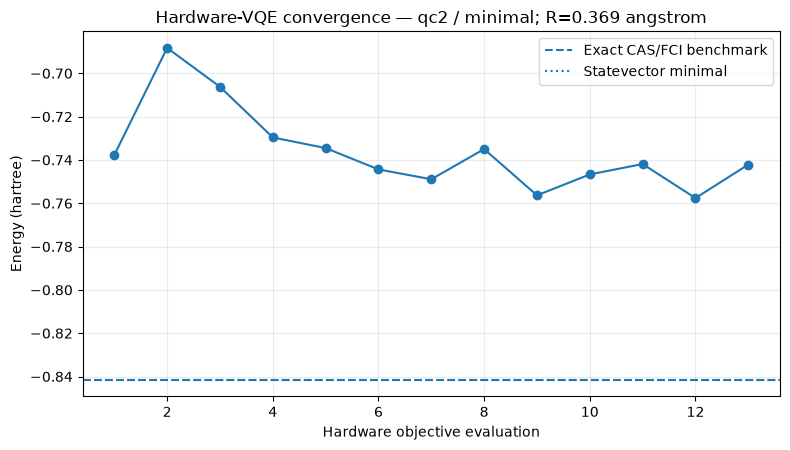

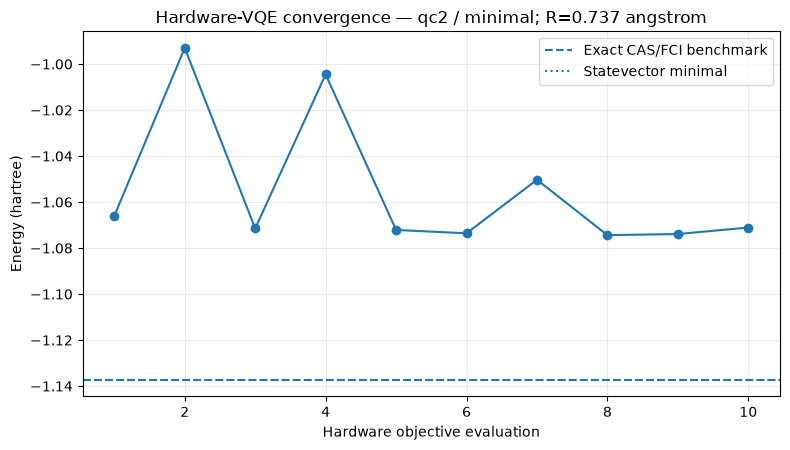

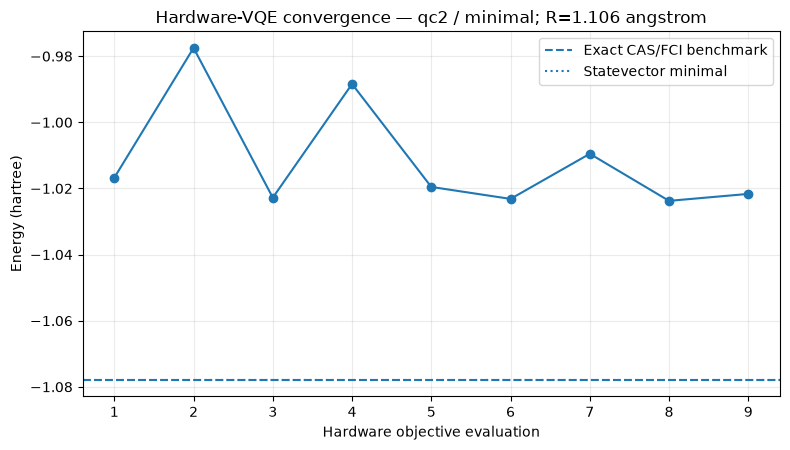

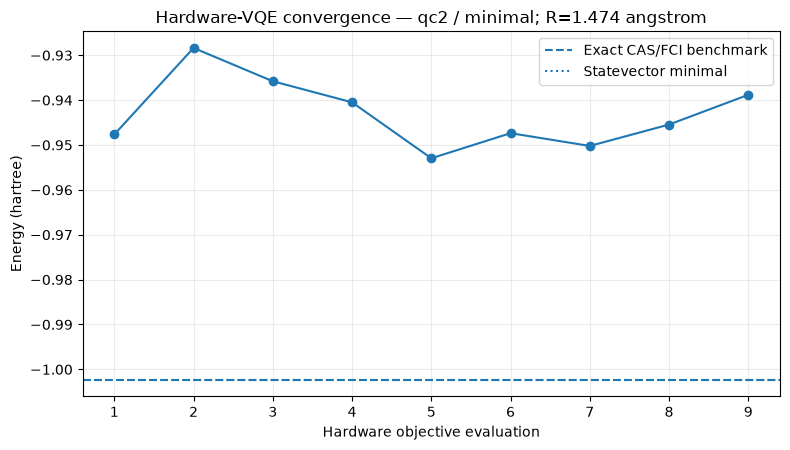

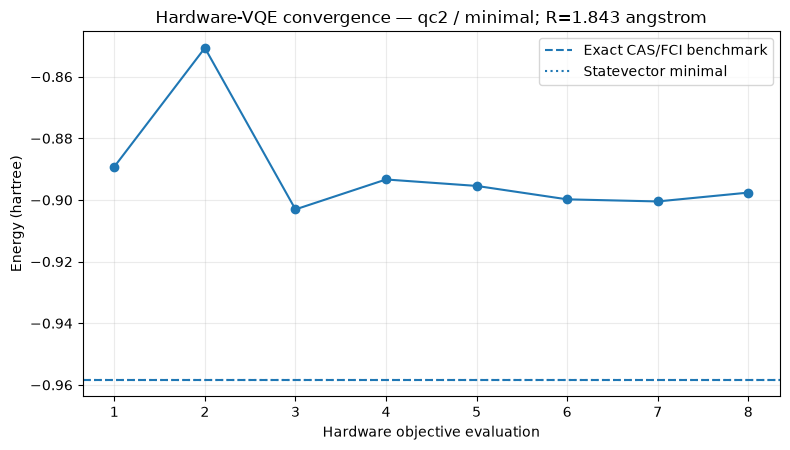

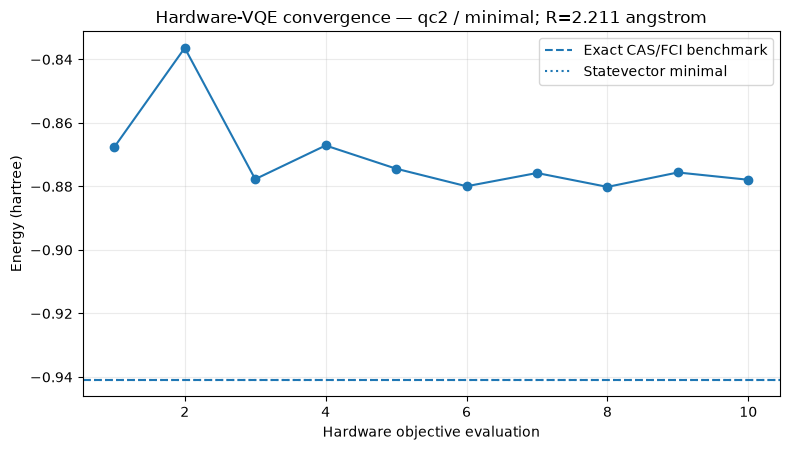

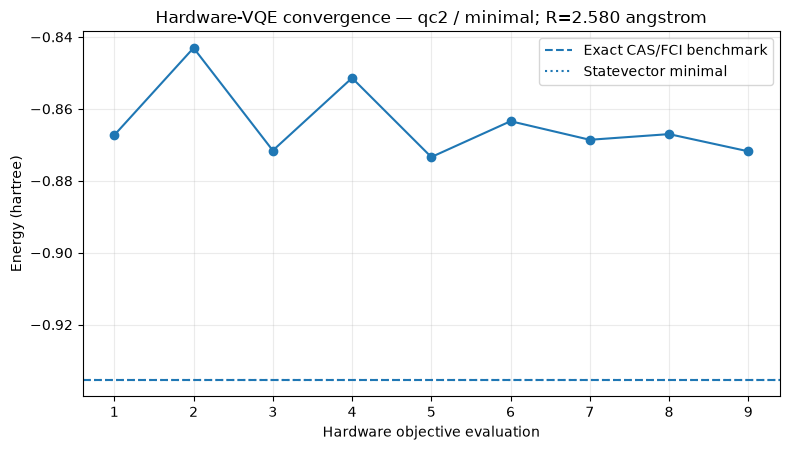

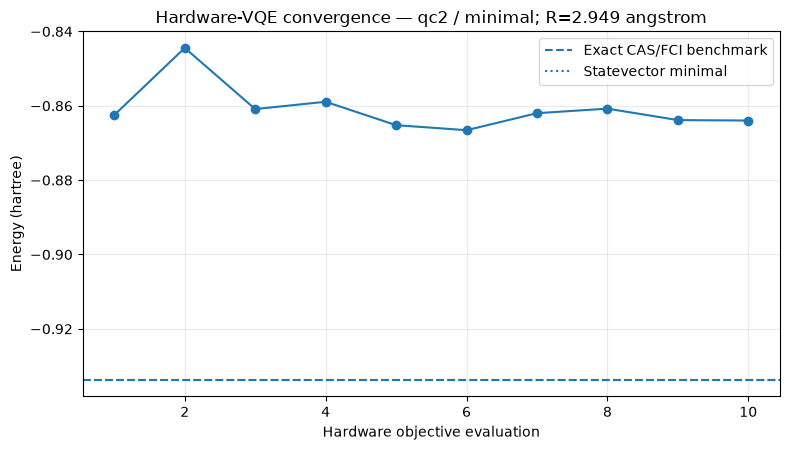

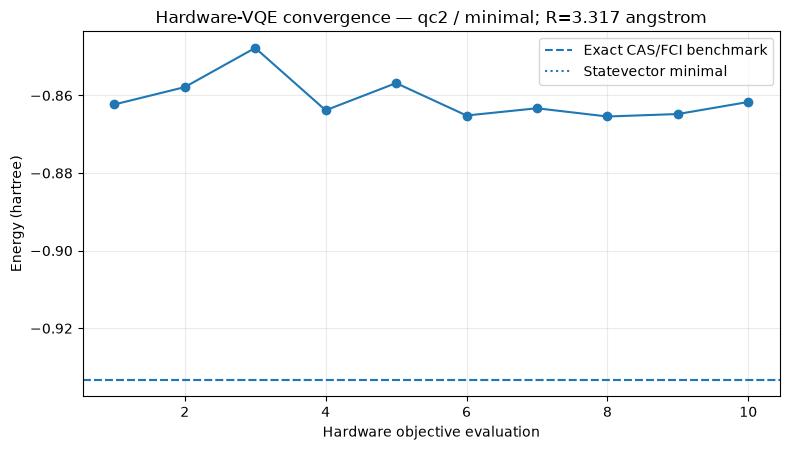

Saved hardware-VQE summary: /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_minimal_qc2_hardware_vqe_full_sv_20260810T122941Z.csv
Saved hardware-VQE provenance: /content/qc2_qi_examples/h2_production_vqe_full_sv/h2_minimal_qc2_hardware_vqe_full_sv_20260810T122941Z.json


In [ ]:
def _json_safe(value):
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, complex):
        return {"real": value.real, "imag": value.imag}
    if isinstance(value, dict):
        return {
            str(key): _json_safe(item)
            for key, item in value.items()
            if key not in {"circuit", "qc2data", "calculator", "ansatz", "reference_state", "mapper"}
        }
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    return value


timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

if h2_hardware_vqe_results:
    for result in h2_hardware_vqe_results:
        hvqe = result["hardware_vqe"]
        history = hvqe.get("objective_history", [])
        if history:
            evaluations = [row["evaluation"] for row in history]
            objectives = [
                row["objective_energy_hartree"] for row in history
            ]

            plt.figure(figsize=(8, 4.6))
            plt.plot(evaluations, objectives, "o-")
            plt.axhline(
                h2_vqe_records[result["point_index"]][
                    "exact_total_energy"
                ],
                linestyle="--",
                label="Exact CAS/FCI benchmark",
            )
            plt.axhline(
                h2_vqe_records[result["point_index"]][
                    "vqe_total_energy"
                ],
                linestyle=":",
                label=f"Statevector {SELECTED_ANSATZ}",
            )
            plt.xlabel("Hardware objective evaluation")
            plt.ylabel("Energy (hartree)")
            plt.title(
                f"Hardware-VQE convergence — {hvqe['driver']} / "
                f"{SELECTED_ANSATZ}; "
                f"R={result['distance_angstrom']:.3f} angstrom"
            )
            plt.grid(alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.show()

            # Parameter trajectories are available for the custom driver.
            parameter_rows = [
                row.get("parameters")
                for row in history
                if row.get("parameters") is not None
            ]
            if len(parameter_rows) == len(history) and parameter_rows:
                parameter_trajectory = np.asarray(
                    parameter_rows,
                    dtype=float,
                )
                plt.figure(figsize=(8, 4.6))
                for parameter_index in range(
                    parameter_trajectory.shape[1]
                ):
                    plt.plot(
                        evaluations,
                        parameter_trajectory[:, parameter_index],
                        "o-",
                        label=f"p{parameter_index}",
                    )
                plt.xlabel("Hardware objective evaluation")
                plt.ylabel("Parameter value (rad)")
                plt.title(
                    f"Hardware-VQE parameter trajectory — "
                    f"{SELECTED_ANSATZ}"
                )
                plt.grid(alpha=0.25)
                if parameter_trajectory.shape[1] <= 8:
                    plt.legend(ncol=2)
                plt.tight_layout()
                plt.show()

    csv_path = WORKDIR / (
        f"h2_{SELECTED_ANSATZ}_{HARDWARE_VQE_DRIVER}_"
        f"hardware_vqe_full_sv_{timestamp}.csv"
    )
    with csv_path.open("w", newline="") as handle:
        fieldnames = [
            "point_index",
            "distance_angstrom",
            "driver",
            "ansatz",
            "number_parameters",
            "exact_total_energy_hartree",
            "statevector_vqe_energy_hartree",
            "statevector_vqe_error_mha",
            "hardware_optimal_parameters_json",
            "optimizer_nfev",
            "optimizer_returned_energy_hartree",
            "confirmation_raw_hartree",
            "confirmation_readout_hartree",
            "confirmation_z_sector_hartree",
            "confirmation_full_sv_hartree",
            "confirmation_full_sv_rem_hartree",
            "confirmation_full_sv_error_mha",
            "confirmation_full_sv_rem_error_mha",
            "variational_full_sv_survival",
            "mean_assignment_fidelity",
            "worst_assignment_condition_number",
        ]
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()

        for result in h2_hardware_vqe_results:
            point_index = result["point_index"]
            record = h2_vqe_records[point_index]
            hvqe = result["hardware_vqe"]
            confirmation = result["confirmation"]
            energies = confirmation["energies"]["variational"]
            errors = confirmation["error_vs_exact_mha"]
            writer.writerow({
                "point_index": point_index,
                "distance_angstrom": result["distance_angstrom"],
                "driver": hvqe["driver"],
                "ansatz": SELECTED_ANSATZ,
                "number_parameters": record["ansatz"].num_parameters,
                "exact_total_energy_hartree": record[
                    "exact_total_energy"
                ],
                "statevector_vqe_energy_hartree": record[
                    "vqe_total_energy"
                ],
                "statevector_vqe_error_mha": record["vqe_error_mha"],
                "hardware_optimal_parameters_json": json.dumps(
                    hvqe["optimal_parameters"]
                ),
                "optimizer_nfev": hvqe["optimizer_nfev"],
                "optimizer_returned_energy_hartree": hvqe[
                    "optimizer_fun_hartree"
                ],
                "confirmation_raw_hartree": energies["raw"],
                "confirmation_readout_hartree": energies["readout"],
                "confirmation_z_sector_hartree": energies[
                    "readout_sector"
                ],
                "confirmation_full_sv_hartree": energies[
                    "readout_full_sv"
                ],
                "confirmation_full_sv_rem_hartree": (
                    confirmation["full_sv_rem_energy"]
                    if APPLY_REM else ""
                ),
                "confirmation_full_sv_error_mha": errors["full_sv"],
                "confirmation_full_sv_rem_error_mha": (
                    errors["full_sv_rem"] if APPLY_REM else ""
                ),
                "variational_full_sv_survival": confirmation[
                    "full_sv_survival"
                ]["variational"],
                "mean_assignment_fidelity": confirmation[
                    "mean_assignment_fidelity"
                ],
                "worst_assignment_condition_number": confirmation[
                    "worst_assignment_condition_number"
                ],
            })

    provenance = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "workflow": "qc2_qi_h2_production_vqe_full_sv",
        "execution_mode": EXECUTION_MODE,
        "hardware_vqe_driver": HARDWARE_VQE_DRIVER,
        "ansatz": SELECTED_ANSATZ,
        "ansatz_spec": ANSATZ_SPECS[SELECTED_ANSATZ],
        "canonical_resources": {
            key: {
                field: value
                for field, value in resource.items()
                if field != "canonical_circuit"
            }
            for key, resource in ansatz_resource_summary.items()
        },
        "qi_resources": ansatz_qi_resource_summary,
        "backend": qi_backend.name,
        "physical_layout_logical_to_physical": list(
            QI_INITIAL_LAYOUT
        ),
        "shots": int(QI_SHOTS),
        "custom_objective_mode": HARDWARE_VQE_OBJECTIVE_MODE,
        "max_evaluations": int(HARDWARE_VQE_MAX_EVALUATIONS),
        "initialization": HARDWARE_VQE_INITIALIZATION,
        "warm_start": bool(HARDWARE_VQE_WARM_START),
        "rhobeg": float(HARDWARE_VQE_RHOBEG),
        "tol": float(HARDWARE_VQE_TOL),
        "full_sv_confirmation": True,
        "apply_rhf_rem": bool(APPLY_REM),
        "rem_reference": "RHF" if APPLY_REM else None,
        "fci_role": "benchmark_only",
        "results": h2_hardware_vqe_results,
    }

    json_path = WORKDIR / (
        f"h2_{SELECTED_ANSATZ}_{HARDWARE_VQE_DRIVER}_"
        f"hardware_vqe_full_sv_{timestamp}.json"
    )
    json_path.write_text(
        json.dumps(_json_safe(provenance), indent=2)
    )

    print("Saved hardware-VQE summary:", csv_path)
    print("Saved hardware-VQE provenance:", json_path)

elif h2_fixed_parameter_results:
    csv_path = WORKDIR / (
        f"h2_{SELECTED_ANSATZ}_fixed_parameter_full_sv_{timestamp}.csv"
    )
    with csv_path.open("w", newline="") as handle:
        fieldnames = [
            "point_index",
            "distance_angstrom",
            "ansatz",
            "statevector_parameters_json",
            "exact_total_energy_hartree",
            "statevector_vqe_energy_hartree",
            "statevector_vqe_error_mha",
            "hardware_raw_hartree",
            "hardware_readout_hartree",
            "hardware_z_sector_hartree",
            "hardware_full_sv_hartree",
            "hardware_full_sv_rem_hartree",
            "hardware_full_sv_error_mha",
            "hardware_full_sv_rem_error_mha",
        ]
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()

        for measurement in h2_fixed_parameter_results:
            point_index = measurement["point_index"]
            record = h2_vqe_records[point_index]
            energies = measurement["energies"]["variational"]
            errors = measurement["error_vs_exact_mha"]
            writer.writerow({
                "point_index": point_index,
                "distance_angstrom": measurement["distance_angstrom"],
                "ansatz": SELECTED_ANSATZ,
                "statevector_parameters_json": json.dumps(
                    record["optimal_parameters"].tolist()
                ),
                "exact_total_energy_hartree": record[
                    "exact_total_energy"
                ],
                "statevector_vqe_energy_hartree": record[
                    "vqe_total_energy"
                ],
                "statevector_vqe_error_mha": record["vqe_error_mha"],
                "hardware_raw_hartree": energies["raw"],
                "hardware_readout_hartree": energies["readout"],
                "hardware_z_sector_hartree": energies[
                    "readout_sector"
                ],
                "hardware_full_sv_hartree": energies[
                    "readout_full_sv"
                ],
                "hardware_full_sv_rem_hartree": (
                    measurement["full_sv_rem_energy"]
                    if APPLY_REM else ""
                ),
                "hardware_full_sv_error_mha": errors["full_sv"],
                "hardware_full_sv_rem_error_mha": (
                    errors["full_sv_rem"] if APPLY_REM else ""
                ),
            })

    provenance = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "workflow": "qc2_qi_h2_production_fixed_parameter_full_sv",
        "execution_mode": EXECUTION_MODE,
        "ansatz": SELECTED_ANSATZ,
        "backend": qi_backend.name,
        "physical_layout_logical_to_physical": list(
            QI_INITIAL_LAYOUT
        ),
        "shots": int(QI_SHOTS),
        "full_sv": True,
        "apply_rhf_rem": bool(APPLY_REM),
        "rem_reference": "RHF" if APPLY_REM else None,
        "fci_role": "benchmark_only",
        "results": h2_fixed_parameter_results,
    }
    json_path = WORKDIR / (
        f"h2_{SELECTED_ANSATZ}_fixed_parameter_full_sv_{timestamp}.json"
    )
    json_path.write_text(
        json.dumps(_json_safe(provenance), indent=2)
    )

    print("Saved fixed-parameter summary:", csv_path)
    print("Saved fixed-parameter provenance:", json_path)
else:
    print("No QI execution results are available yet.")


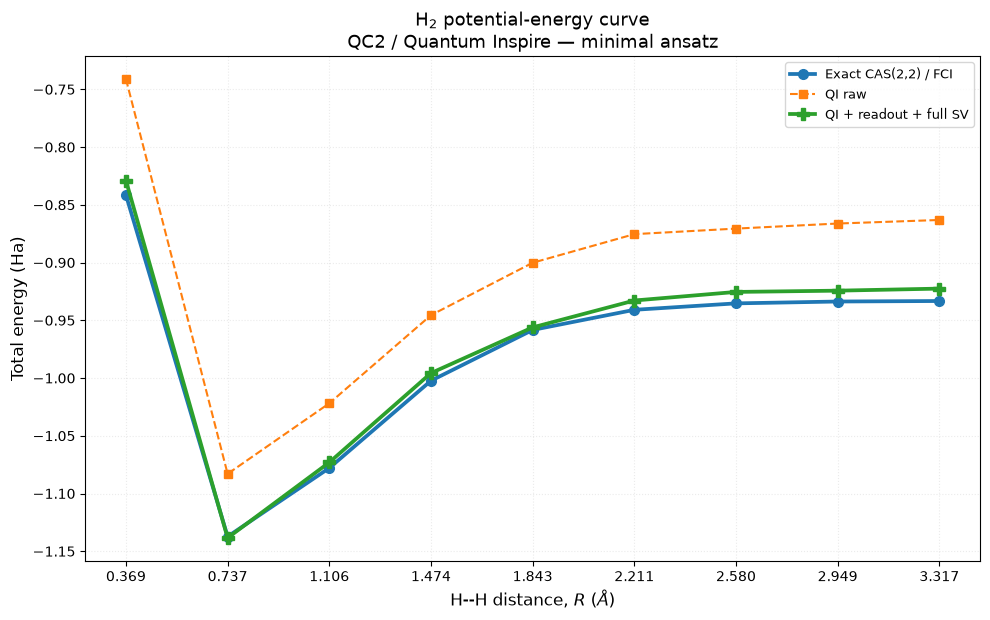


Mean absolute error relative to exact CAS/FCI
----------------------------------------------------
QI raw                        :  65.972 mHa
QI + readout                  :  17.656 mHa
QI + readout + Z-sector       :  12.469 mHa
QI + readout + full SV        :   7.275 mHa


In [ ]:
# ============================================================
# Final H2 potential-energy curve: comparison of methods
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

if not h2_hardware_vqe_results:
    raise RuntimeError(
        "No hardware-VQE results found. Run the hardware-VQE section first."
    )

# Sort explicitly by bond length, so the plot remains correct even if
# selected_qi_points were executed in a different order.
results = sorted(
    h2_hardware_vqe_results,
    key=lambda result: result["distance_angstrom"],
)

# ------------------------------------------------------------
# Collect PEC data
# ------------------------------------------------------------

R = np.asarray(
    [result["distance_angstrom"] for result in results],
    dtype=float,
)

point_indices = [
    result["point_index"]
    for result in results
]

exact = np.asarray(
    [
        h2_vqe_records[i]["exact_total_energy"]
        for i in point_indices
    ],
    dtype=float,
)

rhf = np.asarray(
    [
        h2_vqe_records[i]["reference_energy"]
        for i in point_indices
    ],
    dtype=float,
)

statevector_vqe = np.asarray(
    [
        h2_vqe_records[i]["vqe_total_energy"]
        for i in point_indices
    ],
    dtype=float,
)

optimizer_energy = np.asarray(
    [
        result["hardware_vqe"]["optimizer_fun_hartree"]
        for result in results
    ],
    dtype=float,
)

raw = np.asarray(
    [
        result["confirmation"]["energies"]["variational"]["raw"]
        for result in results
    ],
    dtype=float,
)

readout = np.asarray(
    [
        result["confirmation"]["energies"]["variational"]["readout"]
        for result in results
    ],
    dtype=float,
)

z_sector = np.asarray(
    [
        result["confirmation"]["energies"]["variational"]["readout_sector"]
        for result in results
    ],
    dtype=float,
)

full_sv = np.asarray(
    [
        result["confirmation"]["energies"]["variational"]["readout_full_sv"]
        for result in results
    ],
    dtype=float,
)

# REM is optional in the notebook.
full_sv_rem = np.asarray(
    [
        result["confirmation"].get(
            "full_sv_rem_energy",
            np.nan,
        )
        for result in results
    ],
    dtype=float,
)


# ------------------------------------------------------------
# Plot controls
# ------------------------------------------------------------

SHOW_RHF = False
SHOW_STATEVECTOR = False

# The optimizer-returned energy is the noisy optimization objective,
# not the independent final hardware measurement. Keep False for the
# main publication-style PEC; set True for diagnostic plots.
SHOW_OPTIMIZER_OBJECTIVE = False

SHOW_RAW = True
SHOW_READOUT = False
SHOW_Z_SECTOR = False
SHOW_FULL_SV = True
SHOW_REM = not APPLY_REM


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6.3))

# Classical / noiseless references
if SHOW_RHF:
    ax.plot(
        R,
        rhf,
        "o--",
        linewidth=1.5,
        markersize=6,
        label="RHF / STO-3G",
    )

ax.plot(
    R,
    exact,
    "o-",
    linewidth=2.7,
    markersize=7,
    label="Exact CAS(2,2) / FCI",
)

if SHOW_STATEVECTOR:
    ax.plot(
        R,
        statevector_vqe,
        "^:",
        linewidth=2.0,
        markersize=7,
        label=f"Statevector VQE ({SELECTED_ANSATZ})",
    )

# Noisy optimizer objective -- diagnostic only
if SHOW_OPTIMIZER_OBJECTIVE:
    ax.plot(
        R,
        optimizer_energy,
        "x--",
        linewidth=1.3,
        markersize=7,
        label="QI VQE optimizer objective",
    )

# Independent QPU confirmation
if SHOW_RAW:
    ax.plot(
        R,
        raw,
        "s--",
        linewidth=1.5,
        markersize=6,
        label="QI raw",
    )

if SHOW_READOUT:
    ax.plot(
        R,
        readout,
        "D--",
        linewidth=1.7,
        markersize=6,
        label="QI + correlated readout correction",
    )

if SHOW_Z_SECTOR:
    ax.plot(
        R,
        z_sector,
        "v--",
        linewidth=1.8,
        markersize=6,
        label="QI + readout + Z-sector",
    )

if SHOW_FULL_SV:
    ax.plot(
        R,
        full_sv,
        "P-",
        linewidth=2.7,
        markersize=8,
        label="QI + readout + full SV",
    )

if SHOW_REM and np.any(np.isfinite(full_sv_rem)):
    ax.plot(
        R,
        full_sv_rem,
        "X-.",
        linewidth=1.8,
        markersize=7,
        label="QI + full SV + RHF REM",
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel(r"H--H distance, $R$ ($\AA$)", fontsize=12)
ax.set_ylabel("Total energy (Ha)", fontsize=12)

ax.set_title(
    r"$\mathrm{H_2}$ potential-energy curve"
    "\n"
    f"QC2 / Quantum Inspire — {SELECTED_ANSATZ} ansatz",
    fontsize=13,
)

ax.set_xticks(R)
ax.tick_params(axis="both", labelsize=10)

ax.grid(
    True,
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    fontsize=9,
    frameon=True,
    loc="best",
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Useful aggregate errors printed below the figure
# ------------------------------------------------------------

print("\nMean absolute error relative to exact CAS/FCI")
print("-" * 52)

for name, energy in [
    ("QI raw", raw),
    ("QI + readout", readout),
    ("QI + readout + Z-sector", z_sector),
    ("QI + readout + full SV", full_sv),
]:
    mae_mha = 1000.0 * np.mean(np.abs(energy - exact))
    print(f"{name:30s}: {mae_mha:7.3f} mHa")

if SHOW_REM and np.any(np.isfinite(full_sv_rem)):
    mask = np.isfinite(full_sv_rem)
    mae_mha = 1000.0 * np.mean(
        np.abs(full_sv_rem[mask] - exact[mask])
    )
    print(
        f"{'QI + full SV + RHF REM':30s}: "
        f"{mae_mha:7.3f} mHa"
    )

# 9. Interpretation and reporting guidance

## Primary reported energy

Use:

> **independent confirmation: correlated readout correction + full SV**

as the primary hardware energy.

Report RHF REM separately. REM may help or worsen individual geometries because its bias-transfer assumption is not exact, particularly as H₂ becomes strongly correlated.

## QC2 integration levels demonstrated

### Fixed-parameter / custom VQE path

QC2 supplies:

- electronic structure through PySCF;
- active-space transformation;
- core/inactive energy;
- Qiskit-format qubit Hamiltonian.

The notebook supplies the ansatz/optimizer/hardware execution layer.

### QC2 hardware-VQE path

QC2 additionally supplies/owns the VQE driver. Its VQE calls a Qiskit V2 estimator backed by Quantum Inspire. The classical optimizer runs locally; QI executes the quantum expectation-value circuits.

The current QC2/Qiskit compatibility shim and corrected result wrapper are isolated in Helper 4 so they can be removed cleanly when QC2 migrates fully to the Qiskit V2 primitive API and updates its result handling.

## Scientific caveats

- The H₂-specific `minimal` ansatz and the `IIZZ`/`ZZII` symmetry definitions are specific to this four-qubit CAS(2,2) Jordan–Wigner model.
- `real_amplitudes` and `efficient_su2` do not conserve the target particle-number parity sector by construction. Their full-SV projector survival must therefore be monitored carefully.
- Full SV cannot remove errors that remain inside the correct symmetry sector.
- Error-mitigated finite-shot energies are not guaranteed to preserve a strict variational upper bound.
- Hardware calibration and the best physical layout can drift; re-evaluate the chosen subgraph before a new experimental campaign.


## 10. API references used for this workflow

- QC2 Qiskit VQE API/source: `qc2.algorithms.qiskit.VQE`
- Qiskit Algorithms 0.4 VQE: V2-estimator-based variational eigensolver
- Qiskit `BackendEstimatorV2`: generic `BackendV2` → `BaseEstimatorV2` adapter
- qiskit-quantuminspire: QI provider/backends implement the Qiskit backend interface
- Qiskit `efficient_su2()` / `real_amplitudes()` functions for hardware-efficient ansätze

The environment is deliberately pinned to the versions tested in this notebook rather than silently following package upgrades.


QI job completion is intentionally awaited with `job.result()` and no explicit timeout.


# 11. References and external resources

## Quantum Inspire and Tuna hardware

- **Quantum Inspire:** https://www.quantum-inspire.com/
- **Quantum Inspire backend overview:** https://www.quantum-inspire.com/backends/
- **Superconducting transmon/Tuna backends:** https://www.quantum-inspire.com/backends/transmons/
- **Tuna operational specifics, topology, gate set and scheduling:** https://www.quantum-inspire.com/kbase/tuna-operational-specifics/
- **Getting started with Quantum Inspire transmon backends:** https://www.quantum-inspire.com/kbase/code-example-getting-started-with-transmons/
- **Quantum Inspire public system availability dashboard:** https://monitoring.qutech.support/public-dashboards/b9a0daeda64d4044b88f78b40ba5482a
- **Tuna-9 real-time and historical performance metrics dashboard:** https://monitoring.qutech.support/public-dashboards/9442d29aaa594366a15c97e36da35bab
- **Tuna-17 real-time and historical performance metrics dashboard:** https://monitoring.qutech.support/public-dashboards/98cba4a674c549a2942a0108b2254e9f

## Software repositories and documentation

- **QC2 documentation:** https://qc2.readthedocs.io/
- **QC2 VQE documentation:** https://qc2.readthedocs.io/en/stable/algorithms/vqe_class.html
- **QC2 source repository:** https://github.com/qc2nl/qc2
- **Quantum Inspire CLI/SDK:** https://github.com/QuTech-Delft/quantuminspire
- **Qiskit provider for Quantum Inspire:** https://github.com/QuTech-Delft/qiskit-quantuminspire
- **DiCarlo Lab GitHub organization:** https://github.com/DiCarloLab-Delft/
- **DiCarlo Lab `QuantumInspireUtilities`:** https://github.com/DiCarloLab-Delft/QuantumInspireUtilities
- **Qiskit `BackendEstimatorV2` documentation:** https://qiskit.qotlabs.org/docs/api/qiskit/qiskit.primitives.BackendEstimatorV2


**AI use declaration**: OpenAI's GPT 5.6 Sol was used to generate code/text and perform validation for parts of this notebook.


## Peer-reviewed literature

1. **A. Peruzzo et al.**, “A variational eigenvalue solver on a photonic quantum processor,” *Nature Communications* **5**, 4213 (2014).  
   https://doi.org/10.1038/ncomms5213

2. **P. J. J. O'Malley et al.**, “Scalable Quantum Simulation of Molecular Energies,” *Physical Review X* **6**, 031007 (2016).  
   https://doi.org/10.1103/PhysRevX.6.031007

3. **X. Bonet-Monroig, R. Sagastizabal, M. Singh, and T. E. O'Brien**, “Low-cost error mitigation by symmetry verification,” *Physical Review A* **98**, 062339 (2018).  
   https://doi.org/10.1103/PhysRevA.98.062339

4. **R. Sagastizabal et al.**, “Experimental error mitigation via symmetry verification in a variational quantum eigensolver,” *Physical Review A* **100**, 010302(R) (2019).  
   https://doi.org/10.1103/PhysRevA.100.010302

5. **F. B. Maciejewski, Z. Zimborás, and M. Oszmaniec**, “Mitigation of readout noise in near-term quantum devices by classical post-processing based on detector tomography,” *Quantum* **4**, 257 (2020).  
   https://doi.org/10.22331/q-2020-04-24-257

6. **P. Lolur et al.**, “Reference-State Error Mitigation: A Strategy for High Accuracy Quantum Computation of Chemistry,” *Journal of Chemical Theory and Computation* **19**, 783–789 (2023).  
   https://doi.org/10.1021/acs.jctc.2c00807

7. **Q. Sun et al.**, “PySCF: the Python-based simulations of chemistry framework,” *WIREs Computational Molecular Science* **8**, e1340 (2018).  
   https://doi.org/10.1002/wcms.1340
